# 02 Metaphlan Genus Eda

Notebook canónico. Los datos se leen de `datasets/` y los productos derivados se guardan en `results/`.


In [ ]:
# Canonical notebook setup
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.paths import DATASETS_DIR, analysis_output_dirs

ANALYSIS = '02_metaphlan_genus_eda'
OUTPUTS = analysis_output_dirs(ANALYSIS)
# Guardar figuras nuevas en OUTPUTS['figures'] y tablas en OUTPUTS['tables'].


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../datasets/latinbiota_merge_metaphlan_data.csv', sep = '\t', skiprows=1, index_col = 0)
metadata = pd.read_excel('../data/metadata_LATINBIOTA_MEXICO.xlsx', sheet_name='Data')

In [3]:
data_sp = data[data.index.astype(str).str.contains("g__")]
data_sp = data_sp[~data_sp.index.astype(str).str.contains("t__")]
data_sp = data_sp[~data_sp.index.astype(str).str.contains("s__")]
data_sp = data_sp[~data_sp.index.astype(str).str.contains("unclass")]

In [4]:
for item in data_sp.index:
    if 'unclass' in item:
        print(item)

In [5]:
new = []

for item in data_sp.index:
    new.append(item.split('|g__')[1].replace('|t__', ' ').replace('_', ' '))

In [6]:
data_sp.index = new

In [7]:
data_sp = data_sp.T

In [8]:
data_sp

,Bacteroides,Bifidobacterium,Phocaeicola,Fusicatenibacter,Roseburia,Hominilimicola,Blautia,Faecalibacterium,GGB4605,Ruminococcus,...,Sphingomonas,GGB109105,GGB142492,GGB9763,GGB101460,GGB100295,GGB79087,GGB18111,GGB13711,Pauljensenia
36703_3#10,32.43933,11.20012,10.17307,6.61526,5.25075,4.15566,3.92776,3.55883,3.39242,2.86484,...,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
36703_3#12,0.00000,2.08148,0.00000,1.63042,2.77936,0.02314,2.39343,13.65037,0.00000,11.70037,...,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
36703_3#13,0.01499,1.26326,0.00000,0.05598,3.73623,0.00000,0.46372,20.11008,0.00000,6.14148,...,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
36703_3#14,0.01129,3.93269,0.02558,0.32470,0.16471,0.08696,1.64632,0.50796,0.08947,2.75049,...,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
36703_3#15,0.00000,14.90514,0.00000,0.60660,0.09425,1.44976,3.14182,0.48589,0.10213,4.45759,...,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37082_3#5,9.40124,1.02519,0.60428,0.71803,1.98799,0.00000,0.76897,3.41791,0.01933,5.39807,...,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
37082_3#6,0.00917,6.39327,0.00000,0.03441,2.83173,0.21087,8.96822,21.19863,0.07583,4.45623,...,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
37082_3#7,0.00000,0.25274,0.00000,0.03556,0.00095,0.00838,1.02750,0.39048,0.02288,0.48245,...,0.0,0.0,0.0,0.51948,0.05004,0.01539,0.01503,0.01312,0.00439,0.00000
37082_3#8,0.00000,0.12994,0.00000,0.12848,0.07259,0.00000,2.29130,3.34346,0.02274,0.82096,...,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


In [9]:
# data_sp.to_csv('metaphlan_norm.csv')

In [10]:
min_value = data_sp[data_sp > 0].min().min()

In [11]:
rare = ['37082_3#16',
'37082_2#4',
'37035_2#22',
'37035_7#18',
'36703_3#20',
'36703_3#4']


for id_ in rare:
    try:
        data_sp.drop(id_, axis = 0, inplace = True)
    except:
        pass

In [12]:
data_sp.describe()

,Bacteroides,Bifidobacterium,Phocaeicola,Fusicatenibacter,Roseburia,Hominilimicola,Blautia,Faecalibacterium,GGB4605,Ruminococcus,...,Sphingomonas,GGB109105,GGB142492,GGB9763,GGB101460,GGB100295,GGB79087,GGB18111,GGB13711,Pauljensenia
count,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,...,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000
mean,1.690921,1.831479,1.492513,0.924988,2.123691,0.195034,2.650614,5.836748,0.131757,6.142737,...,0.000038,0.000005,0.000002,0.002610,0.000251,0.000077,0.000076,0.000066,0.000022,0.000004
std,4.372527,3.317671,3.285434,1.452916,3.900893,0.422267,3.490411,7.266920,0.931861,7.101361,...,0.000530,0.000071,0.000034,0.036825,0.003547,0.001091,0.001065,0.000930,0.000311,0.000061
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.076500,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.013500,0.000000,0.121930,0.116520,0.000000,0.530280,0.325430,0.000000,1.240200,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.014990,0.430760,0.000000,0.419760,0.744020,0.036260,1.103740,3.199240,0.000000,3.468130,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.358865,2.131645,1.340390,1.148015,2.458375,0.189180,3.428955,8.593985,0.033825,8.324885,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,34.233810,20.580090,24.019750,11.217700,31.567560,4.155660,20.902210,39.544510,12.621290,38.131240,...,0.007480,0.001000,0.000480,0.519480,0.050040,0.015390,0.015030,0.013120,0.004390,0.000860


In [13]:
data_sp

,Bacteroides,Bifidobacterium,Phocaeicola,Fusicatenibacter,Roseburia,Hominilimicola,Blautia,Faecalibacterium,GGB4605,Ruminococcus,...,Sphingomonas,GGB109105,GGB142492,GGB9763,GGB101460,GGB100295,GGB79087,GGB18111,GGB13711,Pauljensenia
36703_3#10,32.43933,11.20012,10.17307,6.61526,5.25075,4.15566,3.92776,3.55883,3.39242,2.86484,...,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
36703_3#12,0.00000,2.08148,0.00000,1.63042,2.77936,0.02314,2.39343,13.65037,0.00000,11.70037,...,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
36703_3#13,0.01499,1.26326,0.00000,0.05598,3.73623,0.00000,0.46372,20.11008,0.00000,6.14148,...,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
36703_3#14,0.01129,3.93269,0.02558,0.32470,0.16471,0.08696,1.64632,0.50796,0.08947,2.75049,...,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
36703_3#15,0.00000,14.90514,0.00000,0.60660,0.09425,1.44976,3.14182,0.48589,0.10213,4.45759,...,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37082_3#5,9.40124,1.02519,0.60428,0.71803,1.98799,0.00000,0.76897,3.41791,0.01933,5.39807,...,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
37082_3#6,0.00917,6.39327,0.00000,0.03441,2.83173,0.21087,8.96822,21.19863,0.07583,4.45623,...,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
37082_3#7,0.00000,0.25274,0.00000,0.03556,0.00095,0.00838,1.02750,0.39048,0.02288,0.48245,...,0.0,0.0,0.0,0.51948,0.05004,0.01539,0.01503,0.01312,0.00439,0.00000
37082_3#8,0.00000,0.12994,0.00000,0.12848,0.07259,0.00000,2.29130,3.34346,0.02274,0.82096,...,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


In [14]:
cols_otros = data_sp.columns[(data_sp == 0).sum() > 180]

In [15]:
data_sp["otros"] = data_sp[cols_otros].sum(axis=1)

In [16]:
data_sp = data_sp.drop(columns=cols_otros)

In [17]:
data_sp.sum(axis=1)

36703_3#10    99.44636
36703_3#12    91.27979
36703_3#13    94.96973
36703_3#14    98.55128
36703_3#15    98.08929
                ...   
37082_3#5     97.18633
37082_3#6     96.45553
37082_3#7     98.17089
37082_3#8     96.41381
37082_3#9     94.90950
Length: 199, dtype: float64

In [18]:
suma_actual = data_sp.sum(axis=1)
faltante = 100 - suma_actual
data_sp["otros"] += faltante

In [19]:
# data_sp.to_csv('metaphlan_clr_genus_w_zeros.csv')

In [20]:
# pseudocount = min_value
pseudocount = min_value / 2
# print(pseudocount)

# Todas las columnas (incluye "otros" si existe)
cols = data_sp.columns

# Contar cuántos ceros hay por fila en las columnas (excepto que "otros" no tenga ceros normalmente)
num_ceros = (data_sp[cols] == 0).sum(axis=1)

# Reemplazar ceros por el pseudocount
data_sp[cols] = data_sp[cols].replace(0, pseudocount)

# Exceso introducido en cada fila
exceso = num_ceros * pseudocount   # Serie fila a fila

# Cantidad que se debe restar a CADA columna de esa fila
correccion = exceso / len(cols)

# Restar corrección a cada columna para mantener suma total
for c in cols:
    data_sp[c] = data_sp[c] - correccion


In [21]:
data_sp.sum(axis = 1)

36703_3#10    100.0
36703_3#12    100.0
36703_3#13    100.0
36703_3#14    100.0
36703_3#15    100.0
              ...  
37082_3#5     100.0
37082_3#6     100.0
37082_3#7     100.0
37082_3#8     100.0
37082_3#9     100.0
Length: 199, dtype: float64

In [22]:
# data_sp.to_csv('metaphlan_clr_genus_wo_zeros_150_pseudo.csv')

In [23]:
data_sp.sum(axis=1).sort_values()

37035_2#32    100.0
36703_3#2     100.0
37082_1#15    100.0
37035_2#9     100.0
37082_1#28    100.0
              ...  
36703_3#3     100.0
36703_3#25    100.0
37082_2#6     100.0
37082_2#24    100.0
37082_2#12    100.0
Length: 199, dtype: float64

In [24]:
list(data_sp.columns)

['Bacteroides',
 'Bifidobacterium',
 'Phocaeicola',
 'Fusicatenibacter',
 'Roseburia',
 'Hominilimicola',
 'Blautia',
 'Faecalibacterium',
 'GGB4605',
 'Ruminococcus',
 'Anaerostipes',
 'Collinsella',
 'Agathobacter',
 'Alistipes',
 'GGB3612',
 'Faecalibacillus',
 'Dorea',
 'Simiaoa',
 'Hominenteromicrobium',
 'Mediterraneibacter',
 'Waltera',
 'Parabacteroides',
 'Dialister',
 'Candidatus Cibionibacter',
 'Streptococcus',
 'Escherichia',
 'Coprococcus',
 'Clostridium',
 'Agathobaculum',
 'Anaerobutyricum',
 'Ruthenibacterium',
 'Anaerotignum',
 'Phascolarctobacterium',
 'Eggerthella',
 'Eubacterium',
 'Parvimonas',
 'Odoribacter',
 'Lentihominibacter',
 'Lachnoclostridium',
 'Parasutterella',
 'Flavonifractor',
 'Gallintestinimicrobium',
 'Dysosmobacter',
 'Lachnospira',
 'Thomasclavelia',
 'Veillonella',
 'GGB52130',
 'Haemophilus',
 'Intestinibacter',
 'Enterococcus',
 'GGB51491',
 'Actinomyces',
 'Prevotella',
 'Hungatella',
 'Klebsiella',
 'Segatella',
 'GGB3277',
 'GGB4585',
 'GG

In [25]:
# data_sp2.to_csv('../datasets/metaphlan_genus.tsv', sep = '\t')]

In [26]:
# labels = []
# for id_ in data_sp2.index:
#     labels.append(metadata[metadata['Lane'] == id_]['Lifestyle'].iloc[0])

In [27]:
stds = data_sp.std()

In [28]:
stds.max()

np.float64(15.527536559134651)

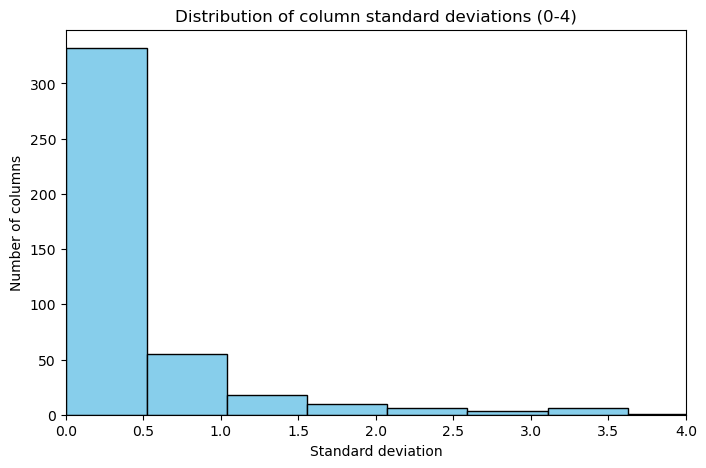

In [29]:
plt.figure(figsize=(8,5))
plt.hist(stds, bins=30, color='skyblue', edgecolor='black')
plt.xlim(0, 4)  # Focus x-axis between 0 and 4
plt.xlabel("Standard deviation")
plt.ylabel("Number of columns")
plt.title("Distribution of column standard deviations (0-4)")
plt.show()

In [30]:
metadata = pd.read_excel('../data/metadata_LATINBIOTA_MEXICO.xlsx', sheet_name='Data')

In [31]:
stds = data_sp.std()

# Seleccionar top 1000 columnas por std
top_cols = stds.sort_values(ascending=False).head(1000).index
data_sp_top = data_sp[top_cols]


In [32]:
data_sp_top

,GGB4916,Segatella,Streptococcus,Faecalibacterium,Ruminococcus,Agathobacter,otros,Bacteroides,Roseburia,Catenibacterium,...,Pusillibacter,GGB13494,GGB3593,GGB52084,GGB9491,GGB52130,GGB99724,Guopingia,Anaerosacchariphilus,GGB58158
36703_3#10,0.000004,0.000004,0.314569,3.558799,2.864809,1.520379,0.753829,32.439299,5.250719,0.000004,...,0.000004,0.000004,0.000004,0.000004,0.000004,0.008259,0.000004,0.000004,0.000004,0.000004
36703_3#12,0.000012,4.067207,0.389957,13.650347,11.700347,4.570637,8.970317,0.000012,2.779337,1.082467,...,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012
36703_3#13,0.000009,22.625344,0.360594,20.110054,6.141454,7.222994,5.759724,0.014964,3.736204,0.336324,...,0.000009,0.000009,0.000104,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009
36703_3#14,0.000006,33.006361,5.611951,0.507931,2.750461,0.503671,17.667201,0.011261,0.164681,2.026181,...,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006
36703_3#15,0.000005,0.400590,2.421450,0.485860,4.457560,44.217820,2.480100,0.000005,0.094220,0.000005,...,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37082_3#5,0.000014,2.729509,0.000014,3.417889,5.398049,6.267289,3.646779,9.401219,1.987969,24.133659,...,0.000014,0.009109,0.009299,0.000014,0.000014,0.000014,0.000014,0.000014,0.000014,0.000014
37082_3#6,0.000008,2.136963,0.376233,21.198603,4.456203,1.410813,3.735083,0.009143,2.831703,9.355843,...,0.000008,0.000008,0.021563,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008
37082_3#7,0.092586,1.944646,0.000021,0.390466,0.482436,0.502706,25.206186,0.000021,0.000936,0.291966,...,0.000021,0.000021,0.007366,0.001166,0.000021,0.000021,0.000726,0.000021,0.000021,0.000021
37082_3#8,0.000022,3.709927,0.082487,3.343447,0.820947,0.238267,14.617617,0.000022,0.072577,1.580817,...,0.000022,0.000022,0.006057,0.000022,0.000022,0.000022,0.002937,0.000022,0.000022,0.000022


In [33]:
rural = list(metadata[metadata['Lifestyle'] == 'Rural']['Lane'])
urban = list(metadata[metadata['Lifestyle'] == 'Urban']['Lane'])

In [34]:
label = []
for x in data_sp.index:
    if x in rural:
        label.append('Rural')
    elif x in urban:
        label.append('Urban')
    else:
        label.append('None')
        

In [35]:
data_sp['label'] = label

C:\Users\rafap\AppData\Local\Temp\ipykernel_12256\1158625544.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_sp['label'] = label


In [36]:
data_sp

,Bacteroides,Bifidobacterium,Phocaeicola,Fusicatenibacter,Roseburia,Hominilimicola,Blautia,Faecalibacterium,GGB4605,Ruminococcus,...,GGB1617,GGB39037,GGB74477,GGB4693,GGB4675,GGB4558,GGB2977,Anaeromassilibacillus,otros,label
36703_3#10,32.439299,11.200089,10.173039,6.615229,5.250719,4.155629,3.927729,3.558799,3.392389,2.864809,...,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.753829,Urban
36703_3#12,0.000012,2.081457,0.000012,1.630397,2.779337,0.023117,2.393407,13.650347,0.000012,11.700347,...,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,8.970317,Rural
36703_3#13,0.014964,1.263234,0.000009,0.055954,3.736204,0.000009,0.463694,20.110054,0.000009,6.141454,...,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,5.759724,Rural
36703_3#14,0.011261,3.932661,0.025551,0.324671,0.164681,0.086931,1.646291,0.507931,0.089441,2.750461,...,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,17.667201,Rural
36703_3#15,0.000005,14.905110,0.000005,0.606570,0.094220,1.449730,3.141790,0.485860,0.102100,4.457560,...,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,2.480100,Rural
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37082_3#5,9.401219,1.025169,0.604259,0.718009,1.987969,0.000014,0.768949,3.417889,0.019309,5.398049,...,0.000014,0.004849,0.000014,0.000014,0.000014,0.000014,0.000014,0.000014,3.646779,Rural
37082_3#6,0.009143,6.393243,0.000008,0.034383,2.831703,0.210843,8.968193,21.198603,0.075803,4.456203,...,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,3.735083,Rural
37082_3#7,0.000021,0.252726,0.000021,0.035546,0.000936,0.008366,1.027486,0.390466,0.022866,0.482436,...,0.266236,0.000021,0.136566,1.098526,0.489306,0.519126,0.000021,0.000021,25.206186,Rural
37082_3#8,0.000022,0.129927,0.000022,0.128467,0.072577,0.000022,2.291287,3.343447,0.022727,0.820947,...,0.158607,0.000022,0.044697,0.000022,0.183517,0.000022,0.005367,0.000022,14.617617,Rural


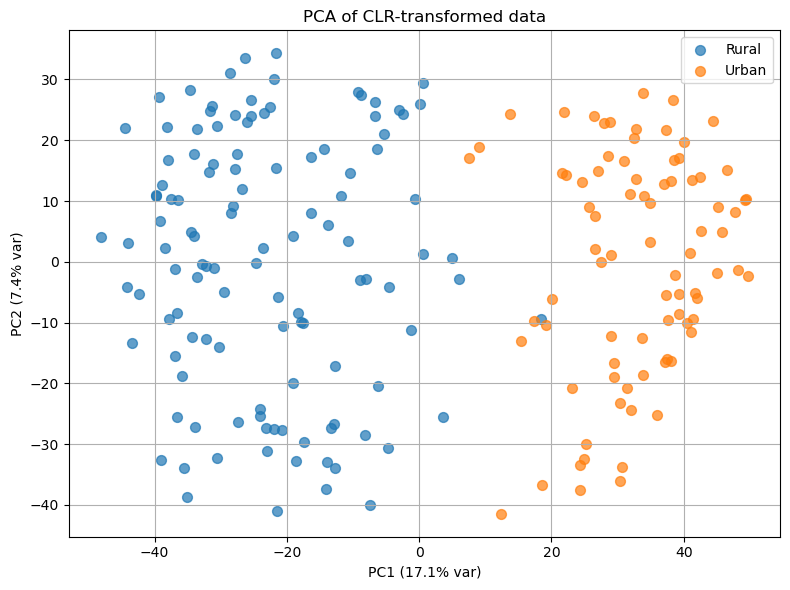

In [37]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X / geom_mean)
    
    return X_clr

# Separate features and labels
X = data_sp.drop(columns=['label']).values
y = data_sp['label'].values

# 1. Apply CLR transformation
# X_clr = X
X_clr = clr_transform(X)

# 2. Optional: Standardization (uncomment if needed)
# scaler = StandardScaler()
# X_clr = scaler.fit_transform(X_clr)

# 3. Perform PCA (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Make a scatter plot
plt.figure(figsize=(8,6))

# Map unique labels to colors
labels_unique = sorted(set(y))
colors = plt.cm.tab10.colors  # up to 10 colors

for i, lbl in enumerate(labels_unique):
    idx = y == lbl
    plt.scatter(X_pca[idx,0], X_pca[idx,1], 
                label=lbl, 
                color=colors[i % len(colors)], 
                alpha=0.7, s=50)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('PCA of CLR-transformed data')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
import math
age_group_list = []
for id_ in data_sp.index:
    try:
        if math.isnan(metadata[metadata['Lane'] == id_]['Age group'].iloc[0]):
            age_group_list.append('Adult')
    except:
        if metadata[metadata['Lane'] == id_]['Age group'].iloc[0] == 'Infant':
            age_group_list.append('Child')
        elif metadata[metadata['Lane'] == id_]['Age group'].iloc[0] == 'Teenager':
            age_group_list.append('Adult')
        else:
            age_group_list.append(metadata[metadata['Lane'] == id_]['Age group'].iloc[0])

In [39]:
data_sp['age_group'] = age_group_list

C:\Users\rafap\AppData\Local\Temp\ipykernel_12256\2685605925.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_sp['age_group'] = age_group_list


In [40]:
import math
health_list = []
for i in range(len(data_sp.index)):
    if age_group_list[i] == 'Adult':
        if metadata[metadata['Lane'] == data_sp.index[i]]['BMI'].iloc[0] < 18.5:
            health_list.append('Bajo')
        elif metadata[metadata['Lane'] == data_sp.index[i]]['BMI'].iloc[0] >= 18.5 and metadata[metadata['Lane'] == data_sp.index[i]]['BMI'].iloc[0] < 25:
            health_list.append('Normal')
        elif metadata[metadata['Lane'] == data_sp.index[i]]['BMI'].iloc[0] >= 25:
            health_list.append('Sobrepeso')
        else:
            health_list.append('Sin datos')
    elif age_group_list[i] == 'Child':
        if metadata[metadata['Lane'] == data_sp.index[i]]['BMI'].iloc[0] < 14:
            health_list.append('Bajo')
        elif metadata[metadata['Lane'] == data_sp.index[i]]['BMI'].iloc[0] >= 14 and metadata[metadata['Lane'] == data_sp.index[i]]['BMI'].iloc[0] < 18:
            health_list.append('Normal')
        elif metadata[metadata['Lane'] == data_sp.index[i]]['BMI'].iloc[0] >= 18:
            health_list.append('Sobrepeso')
        else:
            health_list.append('Sin datos')
    else:
        health_list.append('Sin datos')

In [41]:
data_sp['BMI'] = health_list

C:\Users\rafap\AppData\Local\Temp\ipykernel_12256\132551010.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_sp['BMI'] = health_list


In [42]:
data_sp

,Bacteroides,Bifidobacterium,Phocaeicola,Fusicatenibacter,Roseburia,Hominilimicola,Blautia,Faecalibacterium,GGB4605,Ruminococcus,...,GGB74477,GGB4693,GGB4675,GGB4558,GGB2977,Anaeromassilibacillus,otros,label,age_group,BMI
36703_3#10,32.439299,11.200089,10.173039,6.615229,5.250719,4.155629,3.927729,3.558799,3.392389,2.864809,...,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.753829,Urban,Child,Normal
36703_3#12,0.000012,2.081457,0.000012,1.630397,2.779337,0.023117,2.393407,13.650347,0.000012,11.700347,...,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,8.970317,Rural,Child,Sobrepeso
36703_3#13,0.014964,1.263234,0.000009,0.055954,3.736204,0.000009,0.463694,20.110054,0.000009,6.141454,...,0.000009,0.000009,0.000009,0.000009,0.000009,0.000009,5.759724,Rural,Adult,Normal
36703_3#14,0.011261,3.932661,0.025551,0.324671,0.164681,0.086931,1.646291,0.507931,0.089441,2.750461,...,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,17.667201,Rural,Child,Normal
36703_3#15,0.000005,14.905110,0.000005,0.606570,0.094220,1.449730,3.141790,0.485860,0.102100,4.457560,...,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,2.480100,Rural,Child,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37082_3#5,9.401219,1.025169,0.604259,0.718009,1.987969,0.000014,0.768949,3.417889,0.019309,5.398049,...,0.000014,0.000014,0.000014,0.000014,0.000014,0.000014,3.646779,Rural,Adult,Sobrepeso
37082_3#6,0.009143,6.393243,0.000008,0.034383,2.831703,0.210843,8.968193,21.198603,0.075803,4.456203,...,0.000008,0.000008,0.000008,0.000008,0.000008,0.000008,3.735083,Rural,Child,Normal
37082_3#7,0.000021,0.252726,0.000021,0.035546,0.000936,0.008366,1.027486,0.390466,0.022866,0.482436,...,0.136566,1.098526,0.489306,0.519126,0.000021,0.000021,25.206186,Rural,Adult,Normal
37082_3#8,0.000022,0.129927,0.000022,0.128467,0.072577,0.000022,2.291287,3.343447,0.022727,0.820947,...,0.044697,0.000022,0.183517,0.000022,0.005367,0.000022,14.617617,Rural,Child,Sobrepeso


In [43]:
metadata.head()

,Run,Lane,Sample,Supplier Name,Public Name,Read count,Sample.1,Study,Health state,Disease name,BMI,Antibiotics,Age,Age group,Gender,Lifestyle,Country,Continent
0,37082_3_9,37082_3#9,GI1_LA9438076,50,47,18623506,37082_3_9,Latinbiota,Healthy,NaN,18.1,NaN,7.0,Child,Male,Rural,Mexico,North America
1,37082_3_8,37082_3#8,GI1_LA9438075,49,76,27292796,37082_3_8,Latinbiota,Healthy,NaN,18.7,NaN,9.0,Child,Male,Rural,Mexico,North America
2,37082_3_7,37082_3#7,GI1_LA9438074,47,73,23589062,37082_3_7,Latinbiota,Healthy,NaN,23.5,NaN,23.0,Adult,Female,Rural,Mexico,North America
3,37082_3_6,37082_3#6,GI1_LA9438073,76,161,17556434,37082_3_6,Latinbiota,Healthy,NaN,14.9,NaN,6.0,Child,Male,Rural,Mexico,North America
4,37082_3_5,37082_3#5,GI1_LA9438072,73,159,23119984,37082_3_5,Latinbiota,Healthy,NaN,26.5,NaN,30.0,Adult,Female,Rural,Mexico,North America


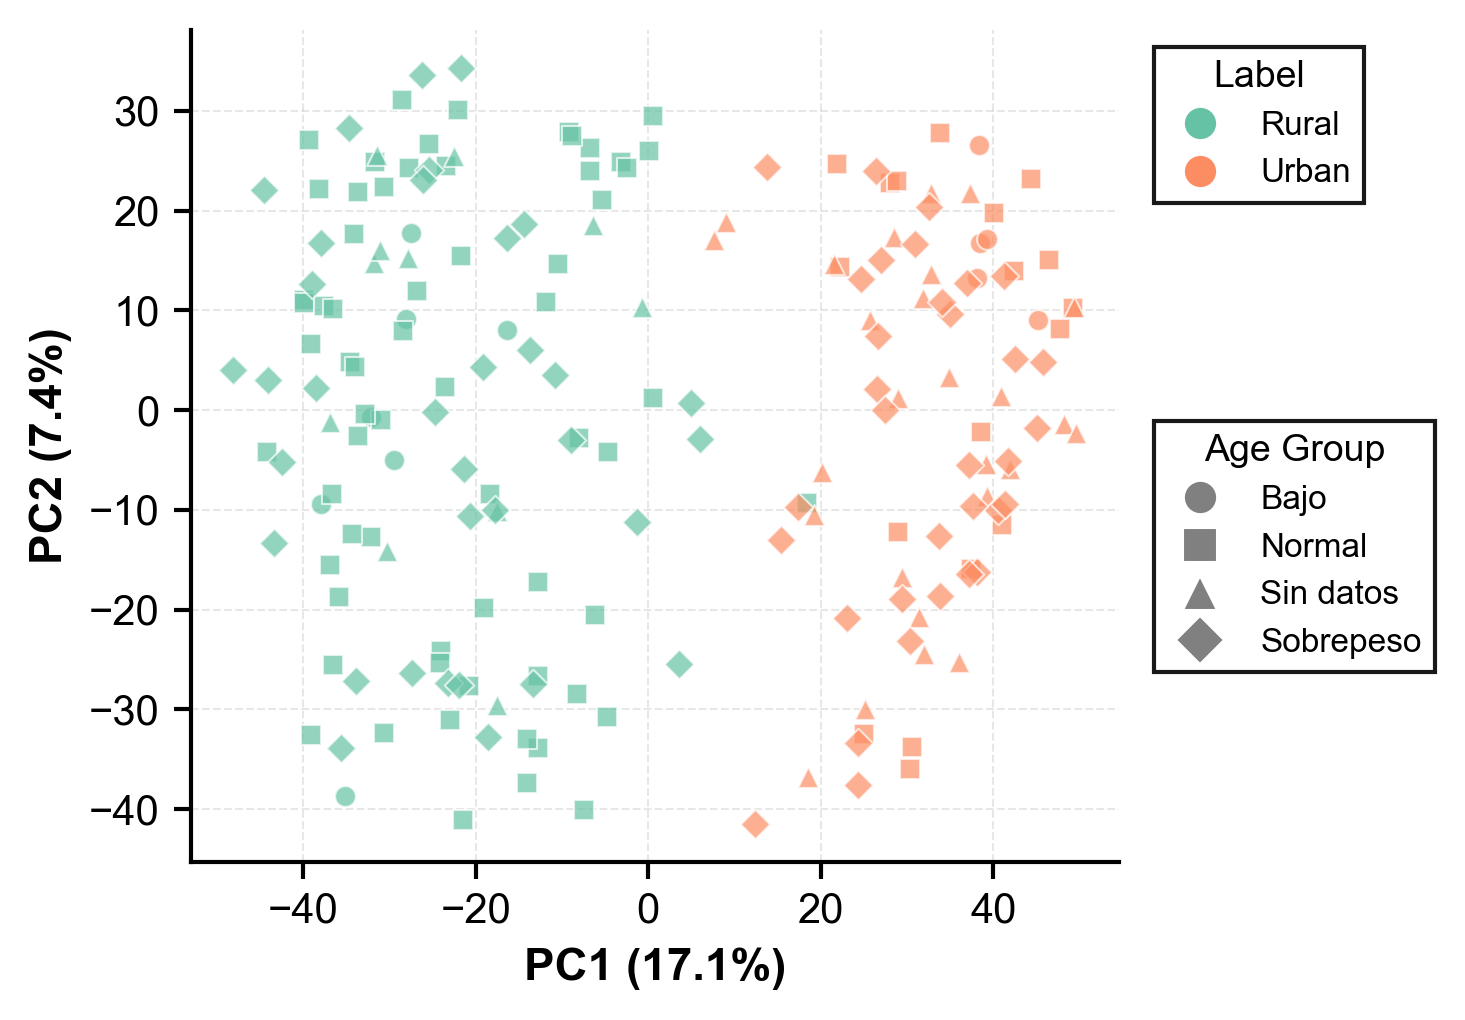

In [44]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D



# Separate features and labels
X = data_sp.drop(columns=['label', 'age_group', 'BMI']).values
y = data_sp['label'].values
age_group = data_sp['BMI'].values  # Make sure this column exists

# 1. Apply CLR transformation
X_clr = clr_transform(X)

# 2. Optional: Standardization (uncomment if needed)
# scaler = StandardScaler()
# X_clr = scaler.fit_transform(X_clr)

# 3. Perform PCA (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

# Create figure with specific size (suitable for journal column width)
fig, ax = plt.subplots(figsize=(5, 3.5), dpi=300)

# Map unique labels to colors
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Map unique age groups to markers
age_groups_unique = sorted(set(age_group))
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

# Plot each combination of label and age group
for i, lbl in enumerate(labels_unique):
    for j, age in enumerate(age_groups_unique):
        idx = (y == lbl) & (age_group == age)
        
        if np.any(idx):
            marker_style = markers[j % len(markers)]
            color = colors[i % len(colors)]
            
            ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
                      color=color,
                      marker=marker_style,
                      alpha=0.7,
                      s=25,
                      edgecolors='white',
                      linewidths=0.5)

# Create custom legend elements AFTER plotting
# Legend for labels (colors)
label_legend_elements = [Line2D([0], [0], marker='o', color='w', 
                                markerfacecolor=colors[i % len(colors)], 
                                markersize=8, label=lbl,
                                markeredgecolor='white', markeredgewidth=0.5)
                        for i, lbl in enumerate(labels_unique)]

# Legend for age groups (markers)
age_legend_elements = [Line2D([0], [0], marker=markers[j % len(markers)], 
                              color='w', markerfacecolor='gray', 
                              markersize=8, label=age,
                              markeredgecolor='white', markeredgewidth=0.5)
                      for j, age in enumerate(age_groups_unique)]

# Add first legend (labels)
first_legend = ax.legend(handles=label_legend_elements, 
                        title='Label',
                        loc='upper left',
                        bbox_to_anchor=(1.02, 1),
                        fontsize=8,
                        title_fontsize=9,
                        frameon=True,
                        edgecolor='black',
                        fancybox=False,
                        framealpha=0.9)

# Add second legend (age groups)
ax.add_artist(first_legend)  # Keep first legend
ax.legend(handles=age_legend_elements,
         title='Age Group',
         loc='upper left',
         bbox_to_anchor=(1.02, 0.55),
         fontsize=8,
         title_fontsize=9,
         frameon=True,
         edgecolor='black',
         fancybox=False,
         framealpha=0.9)

# Format axes
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=11, fontweight='bold')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add subtle grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Optional: Save as high-resolution files for publication
# fig.savefig('pca_clr_analysis.pdf', dpi=300, bbox_inches='tight')
# fig.savefig('pca_clr_analysis_genus.png', dpi=400, bbox_inches='tight')
# fig.savefig('pca_clr_analysis.svg', bbox_inches='tight')

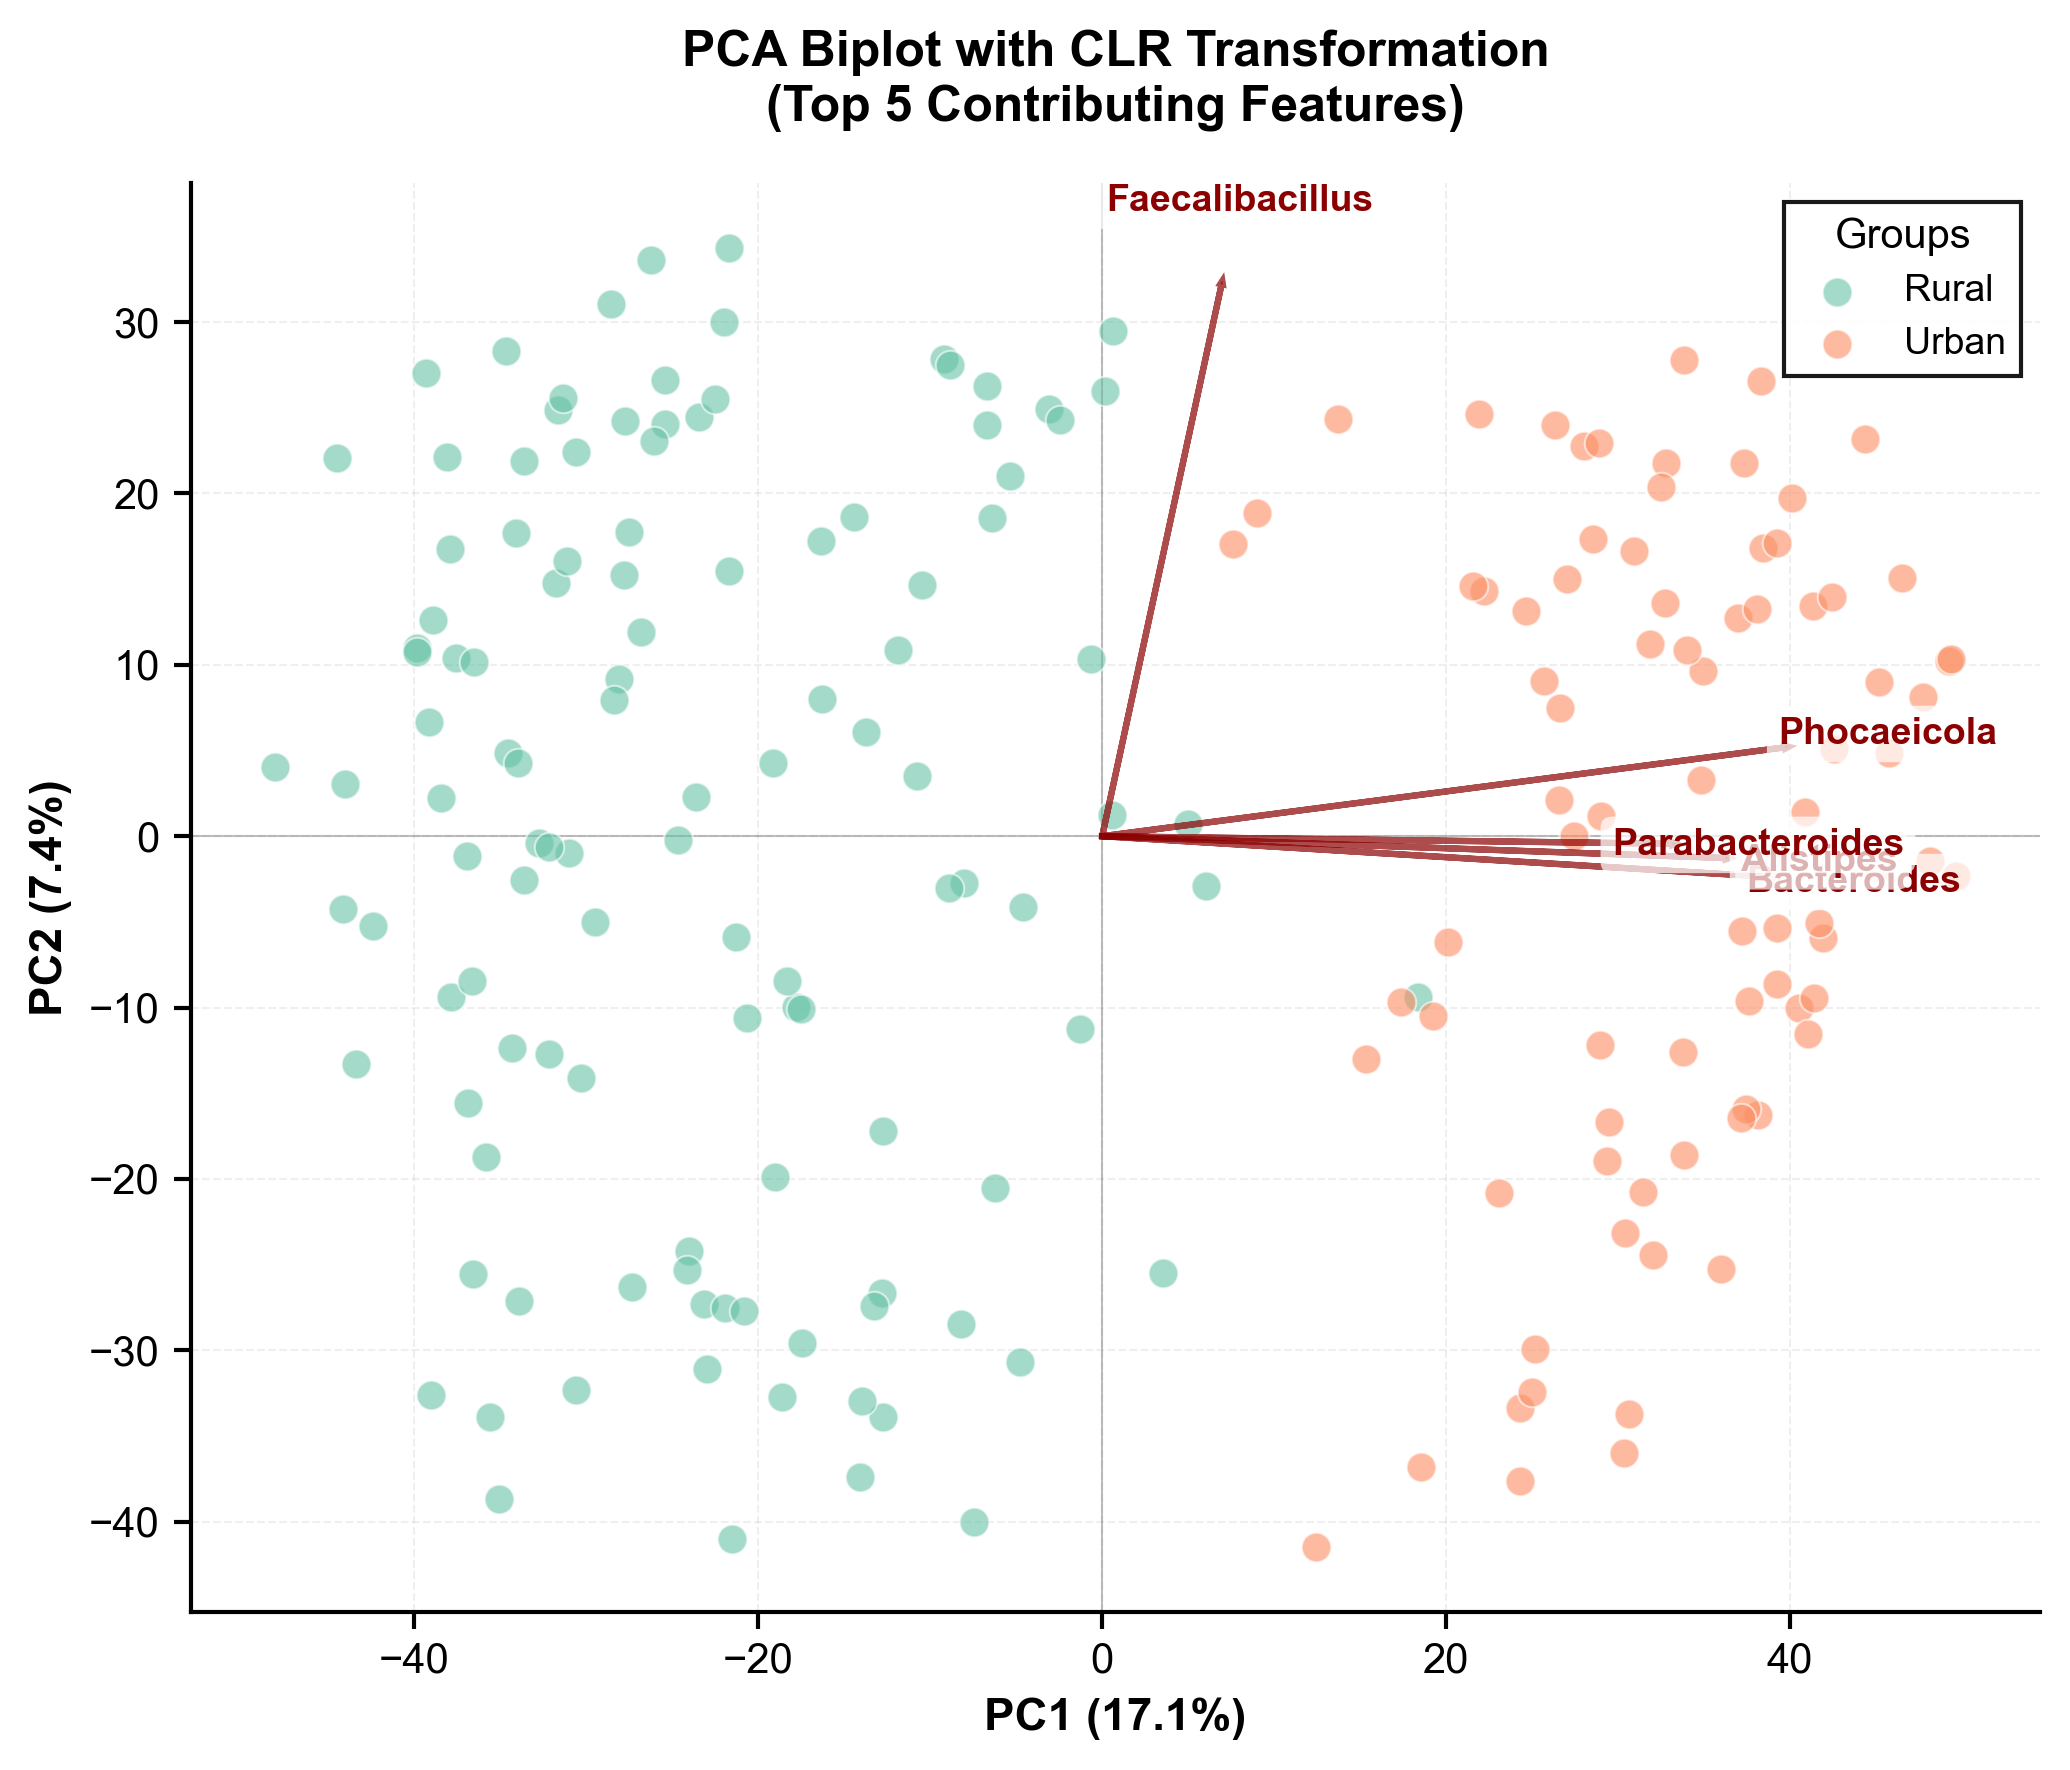

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
#from adjustText import adjustText  # Optional: for better label positioning

# CLR transformation function

# Prepare data
X = data_sp.drop(columns=['label', 'age_group', 'BMI']).values
y = data_sp['label'].values
feature_names = data_sp.drop(columns=['label', 'age_group']).columns

# Apply CLR transformation
X_clr = clr_transform(X)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Loadings (contributions of original variables)
loadings = pca.components_.T  # shape: n_features x 2

# Compute contribution of each feature to PC1+PC2
contrib = np.linalg.norm(loadings, axis=1)  # Euclidean norm across PCs

# Select top 10 features by contribution
top_n = 5
top_idx = np.argsort(contrib)[-top_n:][::-1]  # indices of top features
top_features = feature_names[top_idx]

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

# Create figure
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

# Get unique labels and colors
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Scatter plot of samples
for i, group in enumerate(labels_unique):
    idx = y == group
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], 
              alpha=0.6, 
              s=50, 
              label=group,
              color=colors[i % len(colors)],
              edgecolors='white',
              linewidths=0.5,
              zorder=2)

# Draw arrows for top features
scaling = np.max(np.abs(X_pca)) / np.max(np.abs(loadings)) * 0.8  # Auto-scale arrows
texts = []

for i in top_idx:
    # Draw arrow
    ax.arrow(0, 0, 
            loadings[i, 0] * scaling, 
            loadings[i, 1] * scaling, 
            color='darkred', 
            alpha=0.7, 
            head_width=0.15,
            head_length=0.2,
            linewidth=1.5,
            zorder=3)
    
    # Add text label
    text = ax.text(loadings[i, 0] * scaling * 1.15, 
                   loadings[i, 1] * scaling * 1.15, 
                   feature_names[i],
                   fontsize=9, 
                   color='darkred',
                   ha='center',
                   va='center',
                   fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', 
                           facecolor='white', 
                           edgecolor='none',
                           alpha=0.7),
                   zorder=4)
    texts.append(text)

# Optional: Use adjustText to prevent label overlap
# Uncomment if you have adjustText installed: pip install adjustText
# adjustText(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

# Format axes
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_title('PCA Biplot with CLR Transformation\n(Top 5 Contributing Features)', 
             fontsize=12, fontweight='bold', pad=15)

# Legend
ax.legend(frameon=True, 
          loc='best',
          fontsize=9,
          edgecolor='black',
          fancybox=False,
          shadow=False,
          framealpha=0.9,
          title='Groups',
          title_fontsize=10)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add subtle grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=1)
ax.set_axisbelow(True)

# Add reference lines at origin
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)

plt.tight_layout()
plt.show()

# Optional: Save as high-resolution files for publication
# fig.savefig('pca_biplot_clr.pdf', dpi=300, bbox_inches='tight')
# fig.savefig('pca_biplot_clr_genus.png', dpi=400, bbox_inches='tight')
# fig.savefig('pca_biplot_clr.svg', bbox_inches='tight')

Selected 6 distinct directions from 30 top features
1. Direction 1: GGB4888, Paratractidigestivibacter, Senegalimassilia
2. Direction 2: Streptococcus, Enterococcus, Actinomyces, Sarcina, GGB9370
3. Direction 3: GGB9708, GGB3304, GGB9747, GGB9634, GGB9712, GGB143497, Brotocaccenecus, GGB9602
4. Direction 4: Faecalibacillus, Anaerostipes, Eggerthella
5. Direction 5: Phocaeicola, Bacteroides, Alistipes, Parabacteroides, Odoribacter, Barnesiella
6. Direction 6: Ruthenibacterium, Thomasclavelia, GGB3109, Flavonifractor, Dialister


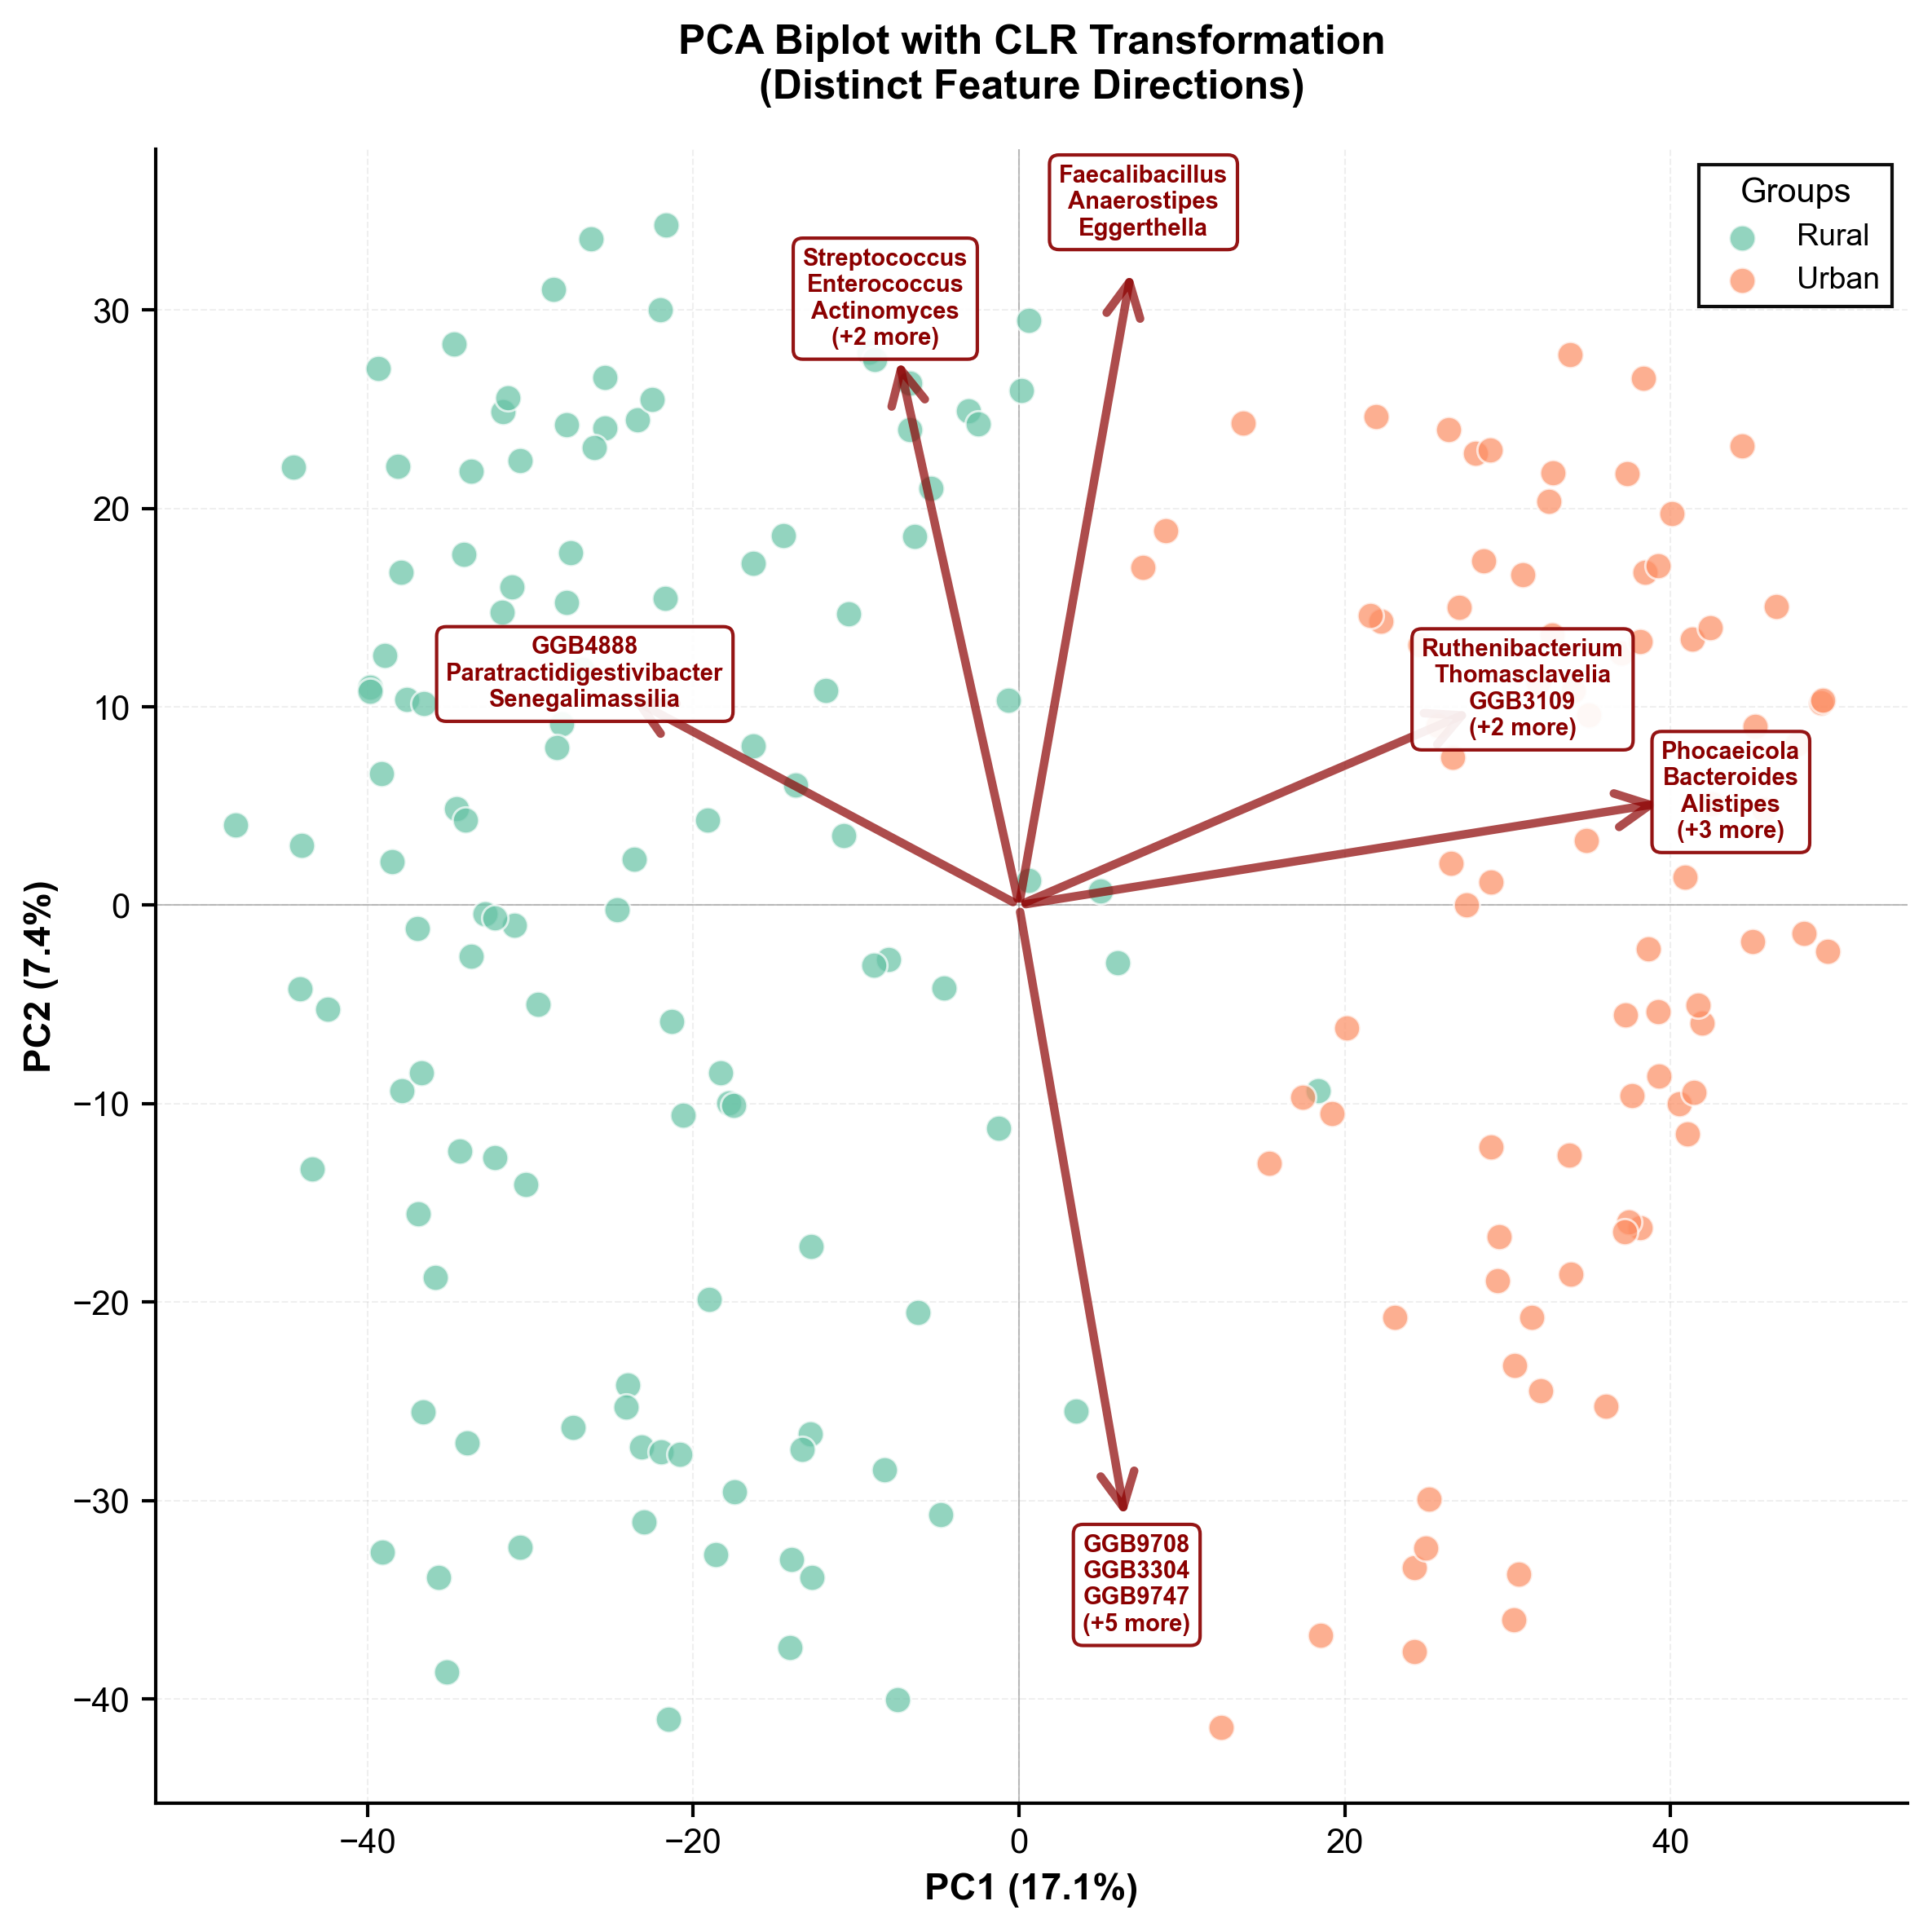

In [46]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    X_safe = X
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X_safe / geom_mean)
    
    return X_clr

# Prepare data
X = data_sp.drop(columns=['label', 'age_group', 'BMI']).values
y = data_sp['label'].values
feature_names = data_sp.drop(columns=['label', 'age_group','BMI']).columns

# Apply CLR transformation
X_clr = clr_transform(X)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Loadings (contributions of original variables)
loadings = pca.components_.T  # shape: n_features x 2

# Compute contribution of each feature to PC1+PC2
contrib = np.linalg.norm(loadings, axis=1)  # Euclidean norm across PCs

# Select top N features by contribution
top_n = 30  # Start with more features, then cluster them
top_idx = np.argsort(contrib)[-top_n:][::-1]
top_loadings = loadings[top_idx]
top_features = feature_names[top_idx]

# Cluster features based on their loading vectors (direction in PC space)
# Use cosine distance to group features pointing in similar directions
distances = pdist(top_loadings, metric='cosine')
linkage_matrix = linkage(distances, method='average')

# Cut tree to get clusters (adjust distance_threshold to control number of groups)
distance_threshold = 0.1  # Lower = more clusters, Higher = fewer clusters
clusters = fcluster(linkage_matrix, distance_threshold, criterion='distance')

# For each cluster, select the feature with highest contribution
selected_features = []
selected_idx = []
for cluster_id in np.unique(clusters):
    cluster_mask = clusters == cluster_id
    cluster_indices = np.where(cluster_mask)[0]
    
    # Find feature with max contribution in this cluster
    cluster_contrib = contrib[top_idx[cluster_indices]]
    best_in_cluster = cluster_indices[np.argmax(cluster_contrib)]
    
    selected_idx.append(top_idx[best_in_cluster])
    
    # Get all features in this cluster for labeling
    cluster_features = [feature_names[top_idx[i]] for i in cluster_indices]
    selected_features.append(cluster_features)

print(f"Selected {len(selected_features)} distinct directions from {top_n} top features")
for i, (idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    print(f"{i+1}. Direction {i+1}: {', '.join(feat_group)}")

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

# Create figure
fig, ax = plt.subplots(figsize=(8, 8), dpi=300)

# Get unique labels and colors
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Add subtle grid FIRST (lowest layer)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Add reference lines at origin
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)

# Scatter plot of samples
for i, group in enumerate(labels_unique):
    idx = y == group
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], 
              alpha=0.7, 
              s=60, 
              label=group,
              color=colors[i % len(colors)],
              edgecolors='white',
              linewidths=0.7,
              zorder=3)

# Draw arrows with all correlated features shown
for i, (feat_idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    # Draw arrow
    ax.annotate('',
               xy=(loadings[feat_idx, 0] * scaling, loadings[feat_idx, 1] * scaling),
               xytext=(0, 0),
               arrowprops=dict(arrowstyle='->',
                             lw=2.5,
                             color='darkred',
                             mutation_scale=25,
                             alpha=0.7),
               zorder=4)
    
    # Show multiple features if they're clustered together
    if len(feat_group) == 1:
        label_text = feat_group[0]
        fontsize = 8
    else:
        # Show up to 4 features, then add "+N more"
        max_show = 3
        if len(feat_group) <= max_show:
            label_text = '\n'.join(feat_group)
        else:
            label_text = '\n'.join(feat_group[:max_show]) + f'\n(+{len(feat_group)-max_show} more)'
        fontsize = 7  # Smaller font for multiple features
    
    # Add text label
    text_offset = 1.1
    text = ax.text(loadings[feat_idx, 0] * scaling * text_offset,
                   loadings[feat_idx, 1] * scaling * text_offset,
                   label_text,
                   fontsize=fontsize,
                   color='darkred',
                   ha='center',
                   va='center',
                   fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.4',
                           facecolor='white',
                           edgecolor='darkred',
                           alpha=0.92,
                           linewidth=1),
                   zorder=5)
    texts.append(text)


# Format axes
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_title('PCA Biplot with CLR Transformation\n(Distinct Feature Directions)', 
             fontsize=12, fontweight='bold', pad=15)

# Legend
ax.legend(frameon=True, 
          loc='best',
          fontsize=9,
          edgecolor='black',
          fancybox=False,
          shadow=False,
          framealpha=0.95,
          title='Groups',
          title_fontsize=10)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Optional: Save as high-resolution files for publication
# fig.savefig('pca_biplot_clr_distinct.pdf', dpi=300, bbox_inches='tight')
# fig.savefig('pca_biplot_clr_genus_distinct.png', dpi=400, bbox_inches='tight')
# fig.savefig('pca_biplot_clr_distinct.svg', bbox_inches='tight')

Selected 6 distinct directions from 30 top features
1. Direction 1: GGB4888, Paratractidigestivibacter, Senegalimassilia
2. Direction 2: Streptococcus, Enterococcus, Actinomyces, Sarcina, GGB9370
3. Direction 3: GGB9708, GGB3304, GGB9747, GGB9634, GGB9712, GGB143497, Brotocaccenecus, GGB9602
4. Direction 4: Faecalibacillus, Anaerostipes, Eggerthella
5. Direction 5: Phocaeicola, Bacteroides, Alistipes, Parabacteroides, Odoribacter, Barnesiella
6. Direction 6: Ruthenibacterium, Thomasclavelia, GGB3109, Flavonifractor, Dialister


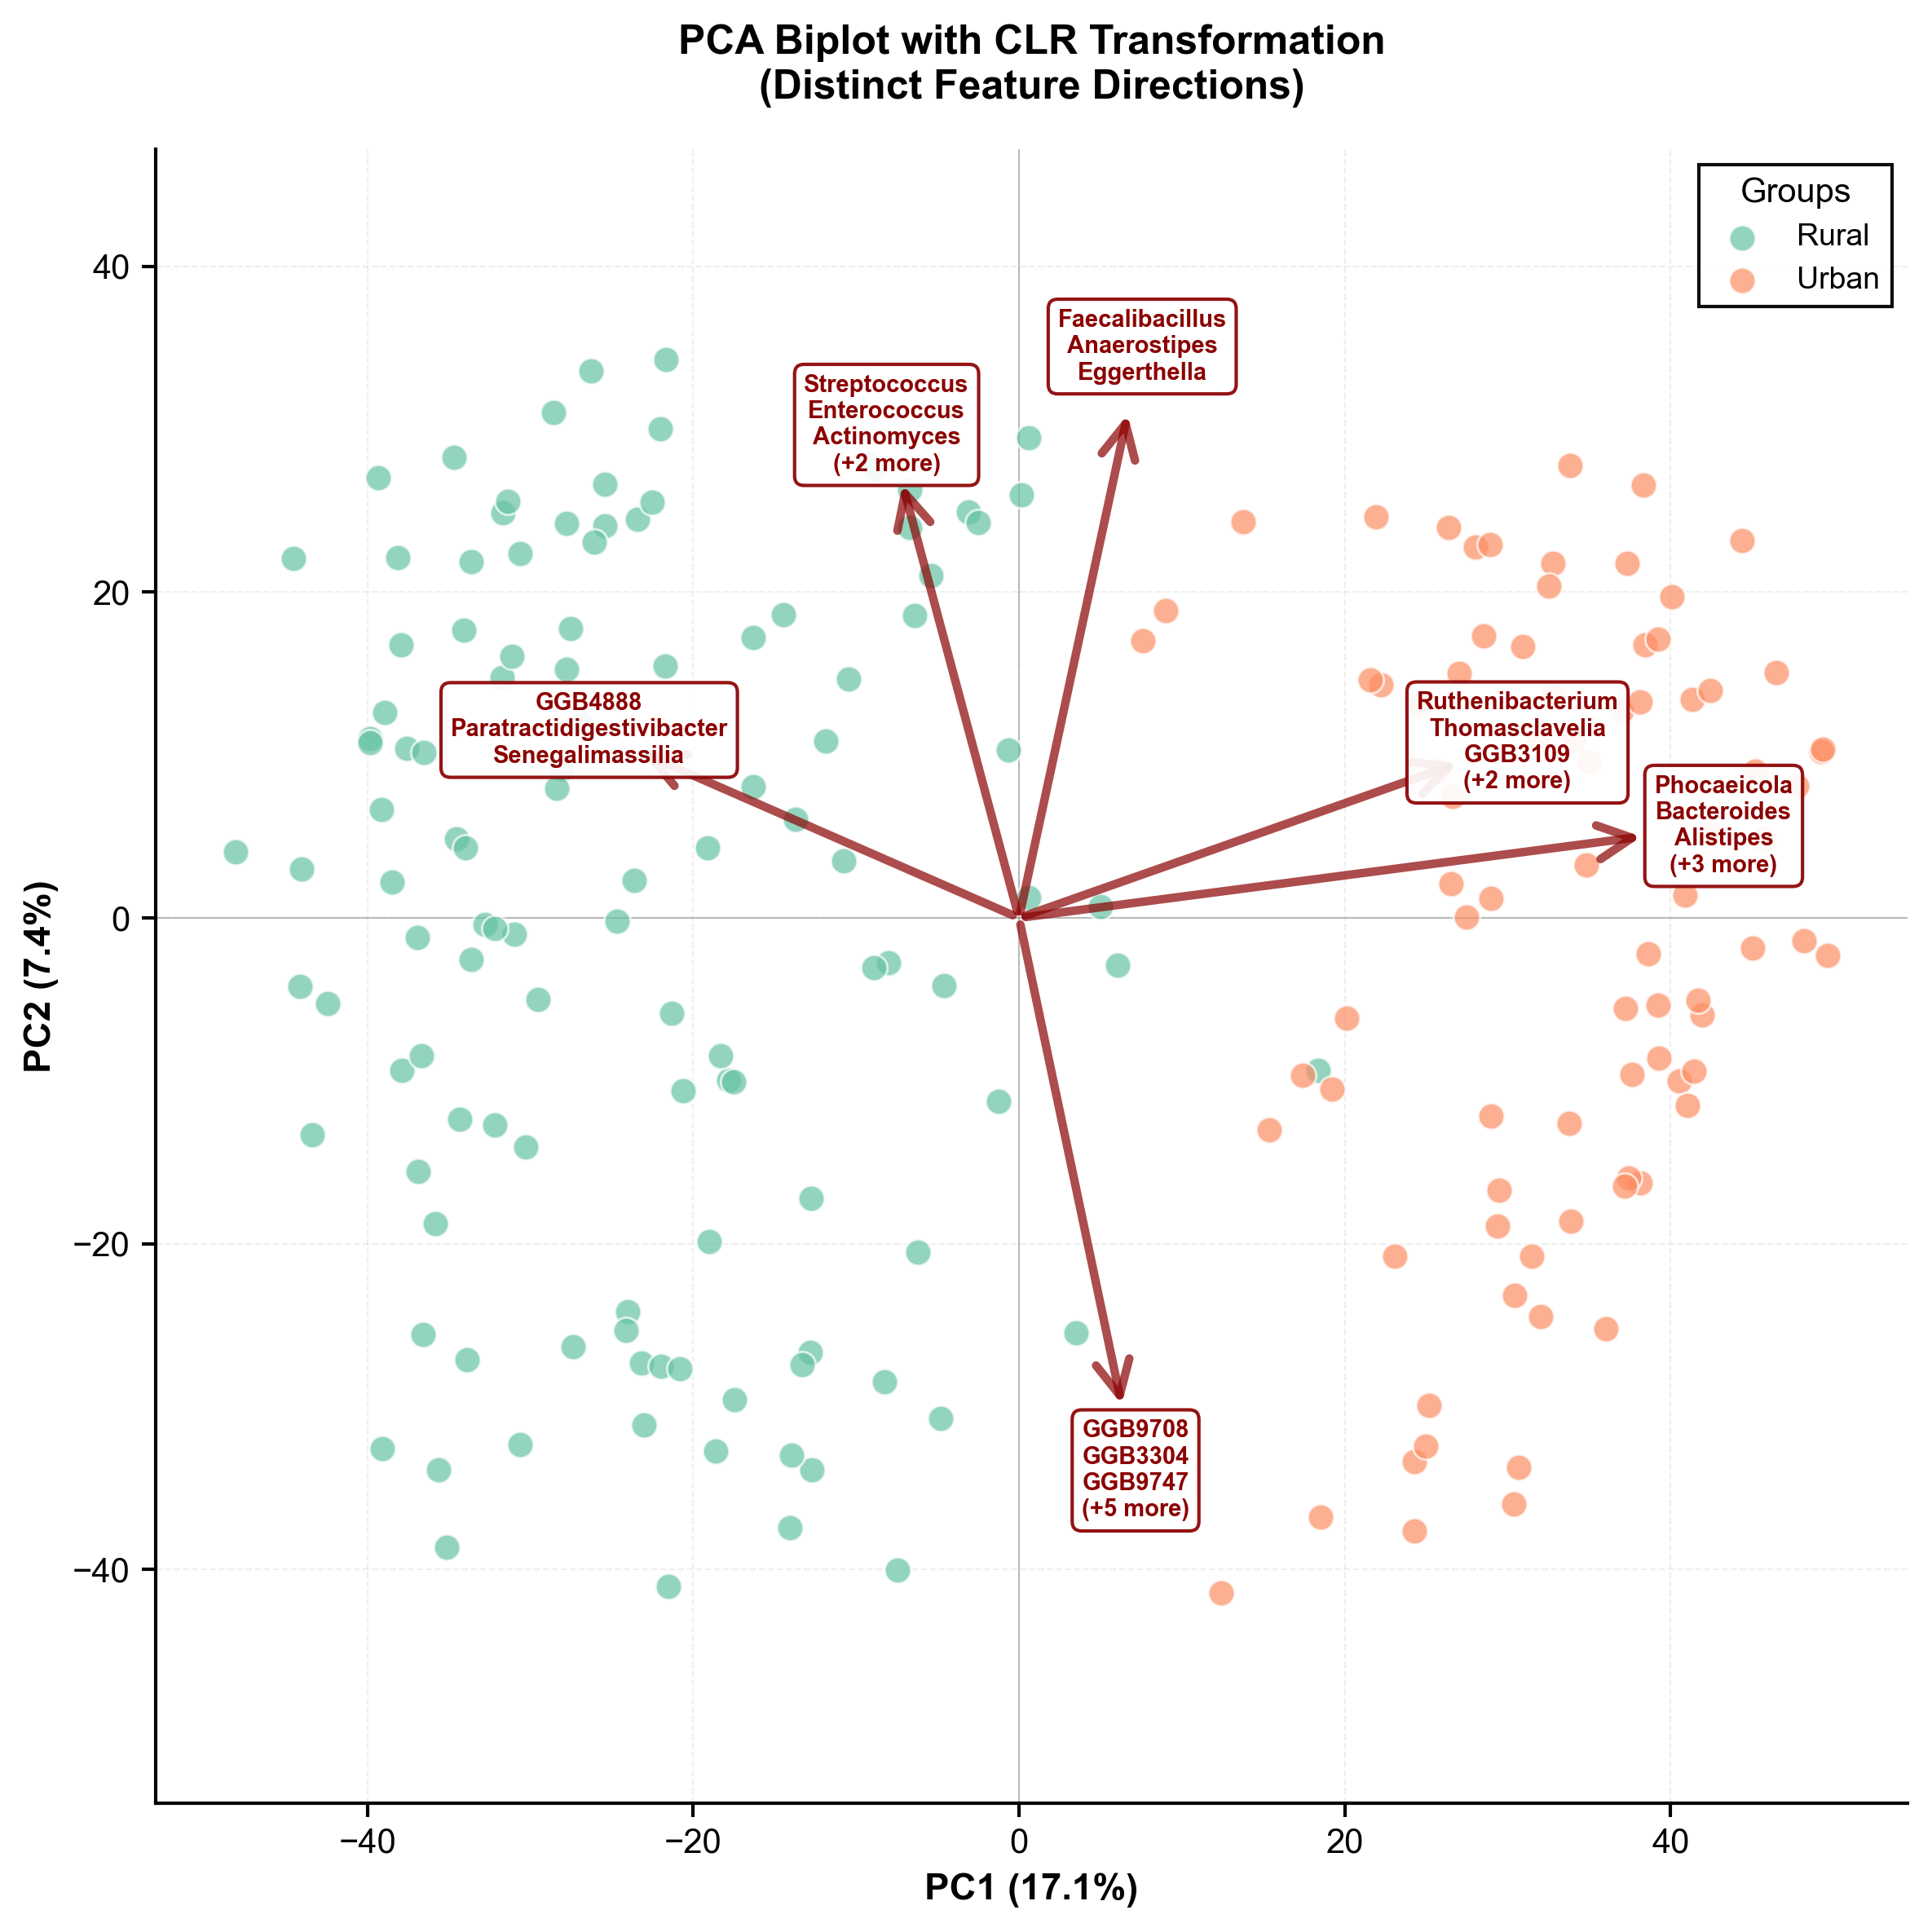

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    X_safe = X
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X_safe / geom_mean)
    
    return X_clr

# Prepare data
X = data_sp.drop(columns=['label', 'age_group', 'BMI']).values
y = data_sp['label'].values
feature_names = data_sp.drop(columns=['label', 'age_group','BMI']).columns

# Apply CLR transformation
X_clr = clr_transform(X)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Loadings (contributions of original variables)
loadings = pca.components_.T  # shape: n_features x 2

# Compute contribution of each feature to PC1+PC2
contrib = np.linalg.norm(loadings, axis=1)  # Euclidean norm across PCs

# Select top N features by contribution
top_n = 30  # Start with more features, then cluster them
top_idx = np.argsort(contrib)[-top_n:][::-1]
top_loadings = loadings[top_idx]
top_features = feature_names[top_idx]

# Cluster features based on their loading vectors (direction in PC space)
# Use cosine distance to group features pointing in similar directions
distances = pdist(top_loadings, metric='cosine')
linkage_matrix = linkage(distances, method='average')

# Cut tree to get clusters (adjust distance_threshold to control number of groups)
distance_threshold = 0.1  # Lower = more clusters, Higher = fewer clusters
clusters = fcluster(linkage_matrix, distance_threshold, criterion='distance')

# For each cluster, select the feature with highest contribution
selected_features = []
selected_idx = []
for cluster_id in np.unique(clusters):
    cluster_mask = clusters == cluster_id
    cluster_indices = np.where(cluster_mask)[0]
    
    # Find feature with max contribution in this cluster
    cluster_contrib = contrib[top_idx[cluster_indices]]
    best_in_cluster = cluster_indices[np.argmax(cluster_contrib)]
    
    selected_idx.append(top_idx[best_in_cluster])
    
    # Get all features in this cluster for labeling
    cluster_features = [feature_names[top_idx[i]] for i in cluster_indices]
    selected_features.append(cluster_features)

print(f"Selected {len(selected_features)} distinct directions from {top_n} top features")
for i, (idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    print(f"{i+1}. Direction {i+1}: {', '.join(feat_group)}")

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

# Create SQUARE figure
fig, ax = plt.subplots(figsize=(8, 8), dpi=300)

# Get unique labels and colors
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Add subtle grid FIRST (lowest layer)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Add reference lines at origin
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)

# Scatter plot of samples
for i, group in enumerate(labels_unique):
    idx = y == group
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], 
              alpha=0.7, 
              s=60, 
              label=group,
              color=colors[i % len(colors)],
              edgecolors='white',
              linewidths=0.7,
              zorder=3)

# Calculate scaling factor for arrows
scaling = 200  # Adjust this value as needed

# Initialize texts list for adjustText (if using it)
texts = []

# Draw arrows with all correlated features shown
for i, (feat_idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    # Draw arrow
    ax.annotate('',
               xy=(loadings[feat_idx, 0] * scaling, loadings[feat_idx, 1] * scaling),
               xytext=(0, 0),
               arrowprops=dict(arrowstyle='->',
                             lw=2.5,
                             color='darkred',
                             mutation_scale=25,
                             alpha=0.7),
               zorder=4)
    
    # Show multiple features if they're clustered together
    if len(feat_group) == 1:
        label_text = feat_group[0]
        fontsize = 8
    else:
        # Show up to 4 features, then add "+N more"
        max_show = 3
        if len(feat_group) <= max_show:
            label_text = '\n'.join(feat_group)
        else:
            label_text = '\n'.join(feat_group[:max_show]) + f'\n(+{len(feat_group)-max_show} more)'
        fontsize = 7  # Smaller font for multiple features
    
    # Add text label
    text_offset = 1.12
    text = ax.text(loadings[feat_idx, 0] * scaling * text_offset,
                   loadings[feat_idx, 1] * scaling * text_offset,
                   label_text,
                   fontsize=fontsize,
                   color='darkred',
                   ha='center',
                   va='center',
                   fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.4',
                           facecolor='white',
                           edgecolor='darkred',
                           alpha=0.92,
                           linewidth=1),
                   zorder=5)
    texts.append(text)

# CRITICAL: Set equal aspect ratio to make plot perfectly square
ax.set_aspect('equal', adjustable='box')

# Get the current axis limits to make them symmetric
x_abs_max = max(abs(ax.get_xlim()[0]), abs(ax.get_xlim()[1]))
y_abs_max = max(abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
max_lim = max(x_abs_max, y_abs_max)

# Set symmetric limits for both axes
# ax.set_xlim(-max_lim, max_lim)
# ax.set_ylim(-max_lim, max_lim)

ax.axis('equal')

# Format axes
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_title('PCA Biplot with CLR Transformation\n(Distinct Feature Directions)', 
             fontsize=12, fontweight='bold', pad=15)

# Legend
ax.legend(frameon=True, 
          loc='best',
          fontsize=9,
          edgecolor='black',
          fancybox=False,
          shadow=False,
          framealpha=0.95,
          title='Groups',
          title_fontsize=10)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Optional: Save as high-resolution files for publication
# fig.savefig('pca_biplot_clr_distinct.pdf', dpi=300, bbox_inches='tight')
# fig.savefig('pca_biplot_clr_genus_distinct.png', dpi=400, bbox_inches='tight')
# fig.savefig('pca_biplot_clr_distinct.svg', bbox_inches='tight')

Seleccionadas 6 direcciones distintas de 30 características principales
1. Dirección 1: GGB4888, Paratractidigestivibacter, Senegalimassilia
2. Dirección 2: Streptococcus, Enterococcus, Actinomyces, Sarcina, GGB9370
3. Dirección 3: GGB9708, GGB3304, GGB9747, GGB9634, GGB9712, GGB143497, Brotocaccenecus, GGB9602
4. Dirección 4: Faecalibacillus, Anaerostipes, Eggerthella
5. Dirección 5: Phocaeicola, Bacteroides, Alistipes, Parabacteroides, Odoribacter, Barnesiella
6. Dirección 6: Ruthenibacterium, Thomasclavelia, GGB3109, Flavonifractor, Dialister


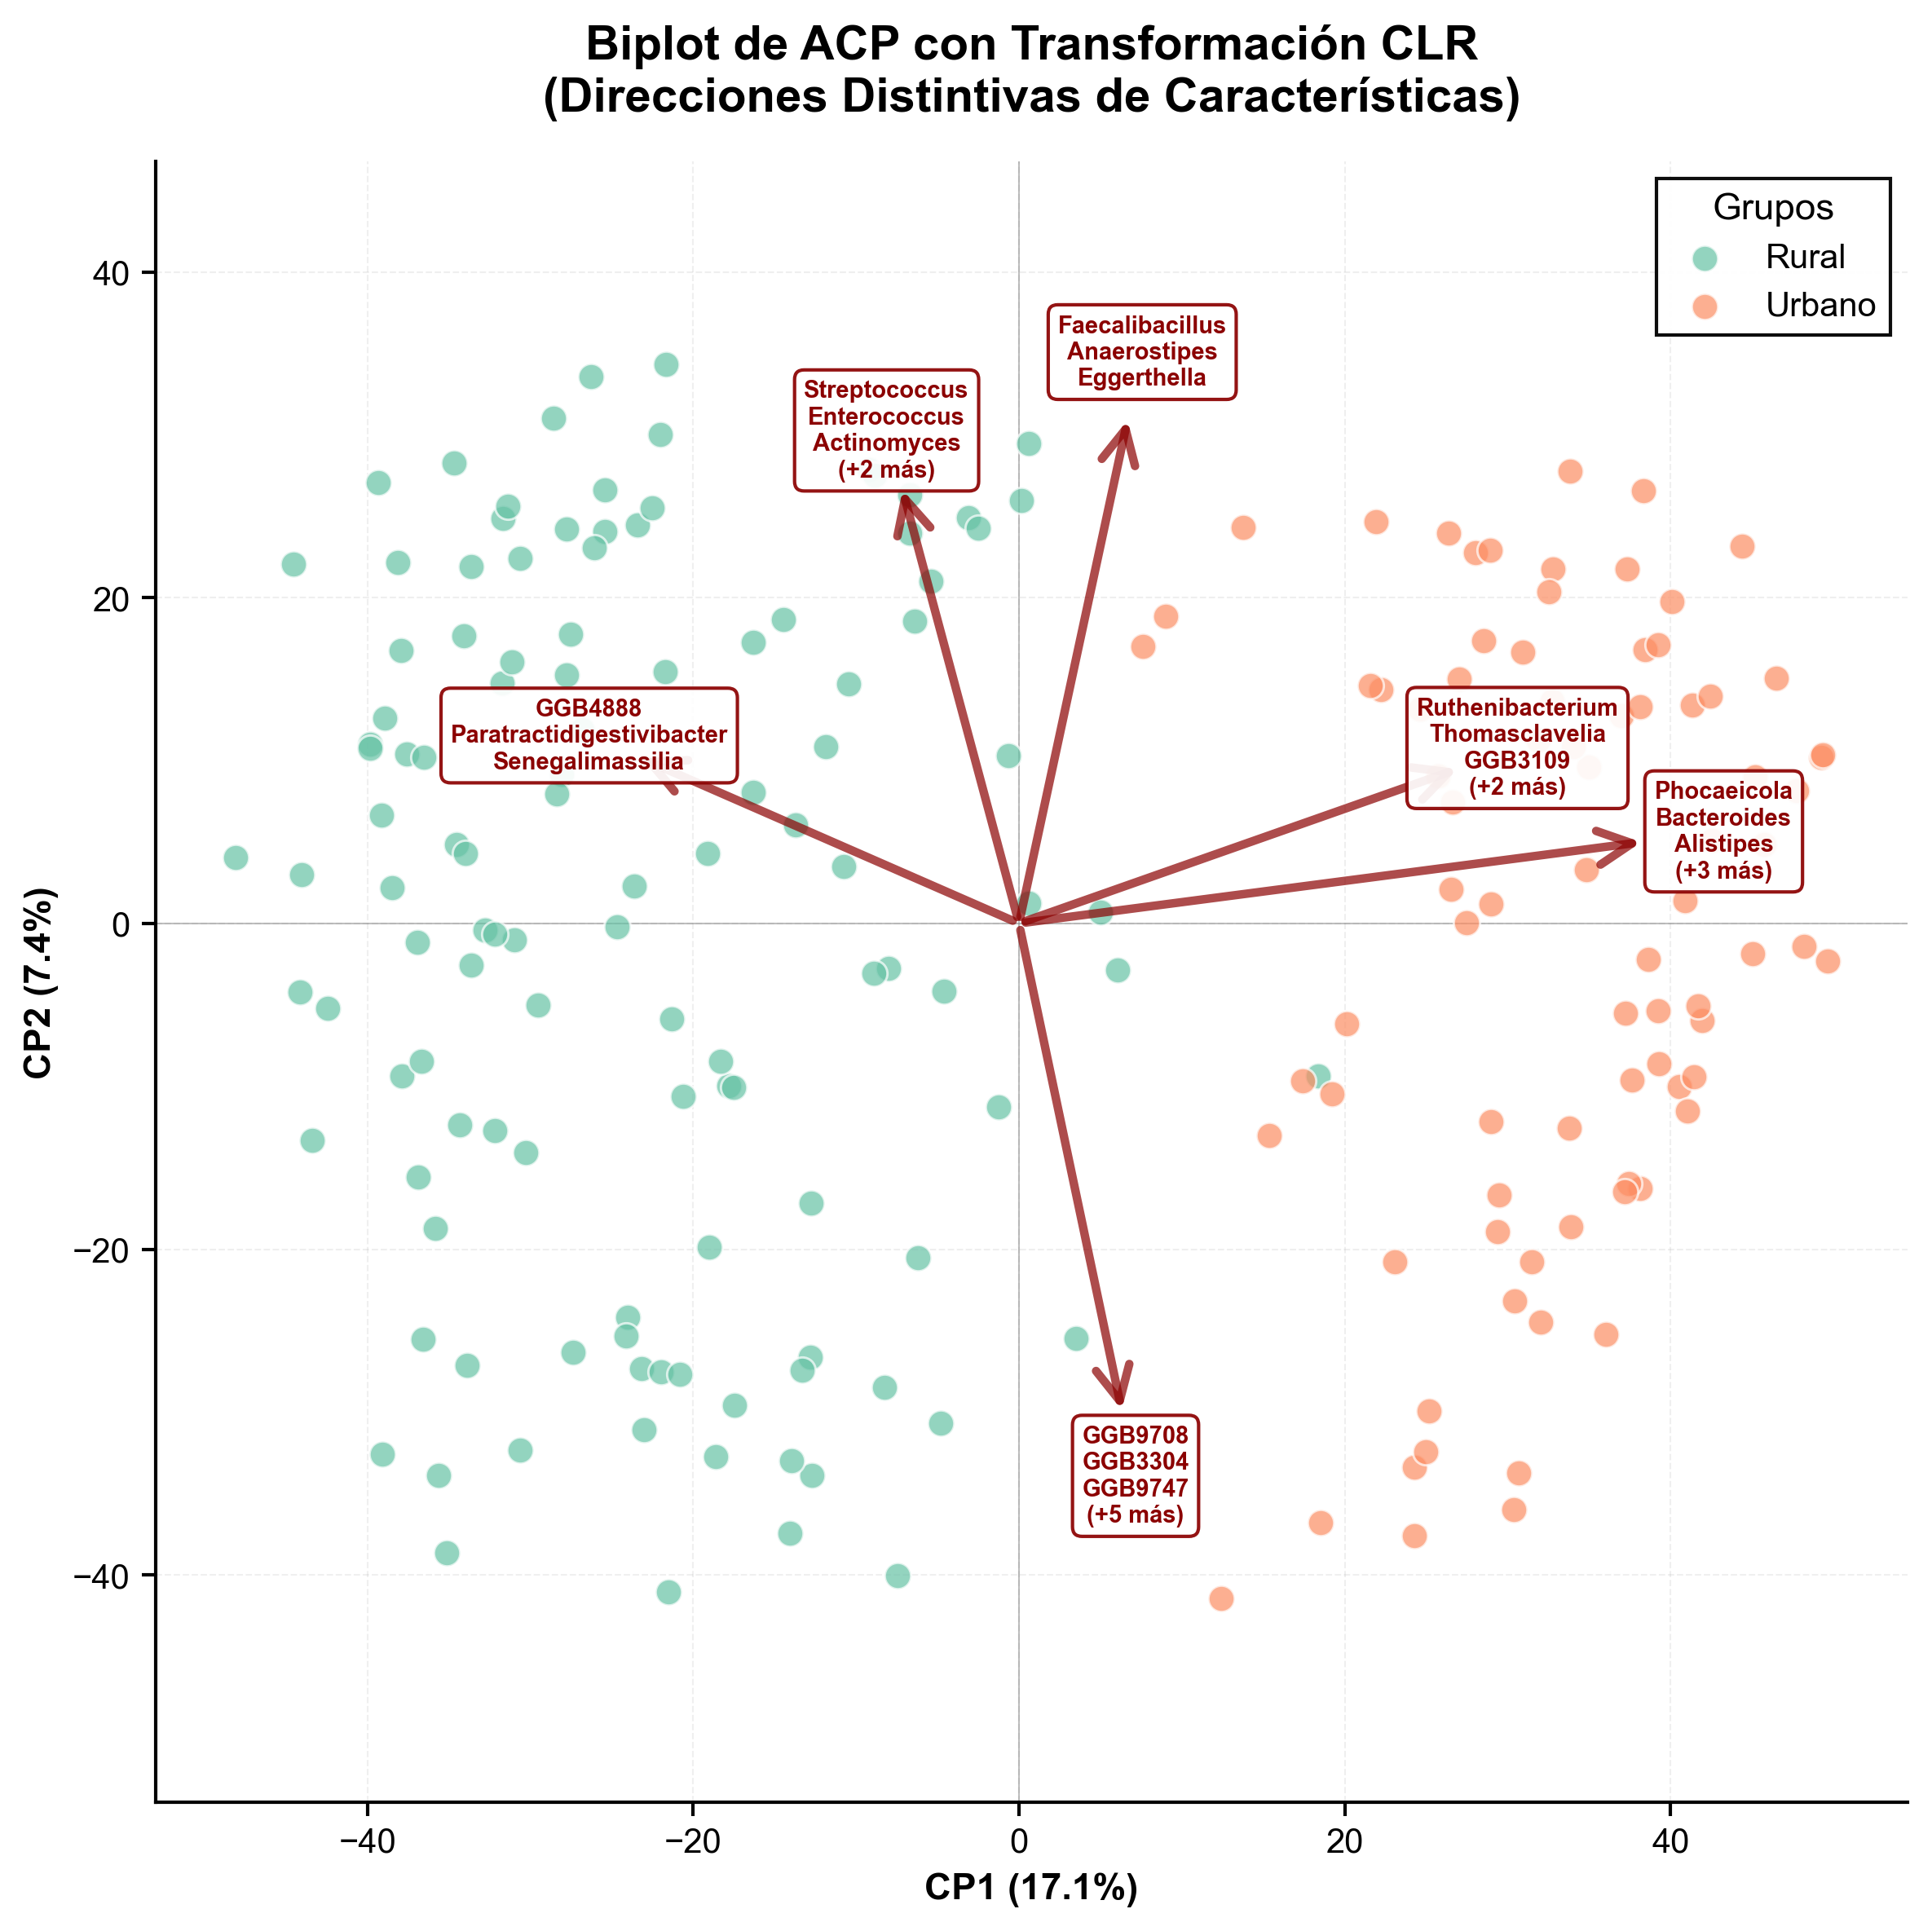

In [48]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    X_safe = X
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X_safe / geom_mean)
    
    return X_clr

# Prepare data
X = data_sp.drop(columns=['label', 'age_group', 'BMI']).values
y = data_sp['label'].values
feature_names = data_sp.drop(columns=['label', 'age_group','BMI']).columns

# Apply CLR transformation
X_clr = clr_transform(X)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Loadings (contributions of original variables)
loadings = pca.components_.T  # shape: n_features x 2

# Compute contribution of each feature to PC1+PC2
contrib = np.linalg.norm(loadings, axis=1)  # Euclidean norm across PCs

# Select top N features by contribution
top_n = 30  # Start with more features, then cluster them
top_idx = np.argsort(contrib)[-top_n:][::-1]
top_loadings = loadings[top_idx]
top_features = feature_names[top_idx]

# Cluster features based on their loading vectors (direction in PC space)
# Use cosine distance to group features pointing in similar directions
distances = pdist(top_loadings, metric='cosine')
linkage_matrix = linkage(distances, method='average')

# Cut tree to get clusters (adjust distance_threshold to control number of groups)
distance_threshold = 0.1  # Lower = more clusters, Higher = fewer clusters
clusters = fcluster(linkage_matrix, distance_threshold, criterion='distance')

# For each cluster, select the feature with highest contribution
selected_features = []
selected_idx = []
for cluster_id in np.unique(clusters):
    cluster_mask = clusters == cluster_id
    cluster_indices = np.where(cluster_mask)[0]
    
    # Find feature with max contribution in this cluster
    cluster_contrib = contrib[top_idx[cluster_indices]]
    best_in_cluster = cluster_indices[np.argmax(cluster_contrib)]
    
    selected_idx.append(top_idx[best_in_cluster])
    
    # Get all features in this cluster for labeling
    cluster_features = [feature_names[top_idx[i]] for i in cluster_indices]
    selected_features.append(cluster_features)

print(f"Seleccionadas {len(selected_features)} direcciones distintas de {top_n} características principales")
for i, (idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    print(f"{i+1}. Dirección {i+1}: {', '.join(feat_group)}")

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

# Create SQUARE figure
fig, ax = plt.subplots(figsize=(8, 8), dpi=300)

# Get unique labels and colors
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Diccionario para traducir etiquetas (ajusta según tus datos)
label_translation = {
    'rural': 'Rural',
    'urban': 'Urbano',
    'Rural': 'Rural',
    'Urban': 'Urbano',
    # Añade más traducciones según sea necesario
}

# Add subtle grid FIRST (lowest layer)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Add reference lines at origin
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)

# Scatter plot of samples
for i, group in enumerate(labels_unique):
    idx = y == group
    # Traducir la etiqueta si existe en el diccionario
    label_es = label_translation.get(group, group)
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], 
              alpha=0.7, 
              s=60, 
              label=label_es,
              color=colors[i % len(colors)],
              edgecolors='white',
              linewidths=0.7,
              zorder=3)

# Calculate scaling factor for arrows
scaling = 200  # Adjust this value as needed

# Initialize texts list for adjustText (if using it)
texts = []

# Draw arrows with all correlated features shown
for i, (feat_idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    # Draw arrow
    ax.annotate('',
               xy=(loadings[feat_idx, 0] * scaling, loadings[feat_idx, 1] * scaling),
               xytext=(0, 0),
               arrowprops=dict(arrowstyle='->',
                             lw=2.5,
                             color='darkred',
                             mutation_scale=25,
                             alpha=0.7),
               zorder=4)
    
    # Show multiple features if they're clustered together
    if len(feat_group) == 1:
        label_text = feat_group[0]
        fontsize = 8
    else:
        # Show up to 4 features, then add "+N more"
        max_show = 3
        if len(feat_group) <= max_show:
            label_text = '\n'.join(feat_group)
        else:
            label_text = '\n'.join(feat_group[:max_show]) + f'\n(+{len(feat_group)-max_show} más)'
        fontsize = 7  # Smaller font for multiple features
    
    # Add text label
    text_offset = 1.12
    text = ax.text(loadings[feat_idx, 0] * scaling * text_offset,
                   loadings[feat_idx, 1] * scaling * text_offset,
                   label_text,
                   fontsize=fontsize,
                   color='darkred',
                   ha='center',
                   va='center',
                   fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.4',
                           facecolor='white',
                           edgecolor='darkred',
                           alpha=0.92,
                           linewidth=1),
                   zorder=5)
    texts.append(text)

# CRITICAL: Set equal aspect ratio to make plot perfectly square
ax.set_aspect('equal', adjustable='box')

# Get the current axis limits to make them symmetric
x_abs_max = max(abs(ax.get_xlim()[0]), abs(ax.get_xlim()[1]))
y_abs_max = max(abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
max_lim = max(x_abs_max, y_abs_max)

# Set symmetric limits for both axes (opcional, comentado porque usas axis('equal'))
# ax.set_xlim(-max_lim, max_lim)
# ax.set_ylim(-max_lim, max_lim)

ax.axis('equal')

# Format axes
ax.set_xlabel(f'CP1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_ylabel(f'CP2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_title('Biplot de ACP con Transformación CLR\n(Direcciones Distintivas de Características)', 
             fontsize=14, fontweight='bold', pad=15)

# Legend
ax.legend(frameon=True, 
          loc='best',
          fontsize=10,
          edgecolor='black',
          fancybox=False,
          shadow=False,
          framealpha=0.95,
          title='Grupos',
          title_fontsize=11)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Optional: Save as high-resolution files for publication
# fig.savefig('biplot_acp_clr_distinto.pdf', dpi=300, bbox_inches='tight')
# fig.savefig('biplot_acp_clr_genero_distinto.png', dpi=400, bbox_inches='tight')
# fig.savefig('biplot_acp_clr_distinto.svg', bbox_inches='tight')

Seleccionadas 8 direcciones distintas de 30 características principales
1. Dirección 1: Streptococcus, Sarcina, Enterococcus
2. Dirección 2: GGB4888, GGB9370, Senegalimassilia, Paratractidigestivibacter, GGB3588
3. Dirección 3: Faecalibacillus, Anaerostipes, Eggerthella
4. Dirección 4: Phocaeicola, Bacteroides, Alistipes, Parabacteroides
5. Dirección 5: Thomasclavelia, GGB3109, Ruthenibacterium, Flavonifractor, Dialister
6. Dirección 6: Methanobrevibacter, GGB3306
7. Dirección 7: GGB9708, GGB9747, GGB3304, GGB143497, Brotocaccenecus, GGB9707
8. Dirección 8: Dysosmobacter, GGB9699

TOP GÉNEROS CONTRIBUYENTES Y SUS CONTRIBUCIONES A LOS COMPONENTES PRINCIPALES

Ranking  Género                         Contrib Total   CP1          CP2         
--------------------------------------------------------------------------------
1        Phocaeicola                          0.2183       0.1931      0.0252
2        Thomasclavelia                       0.1979       0.1091      0.0888
3        Bacte

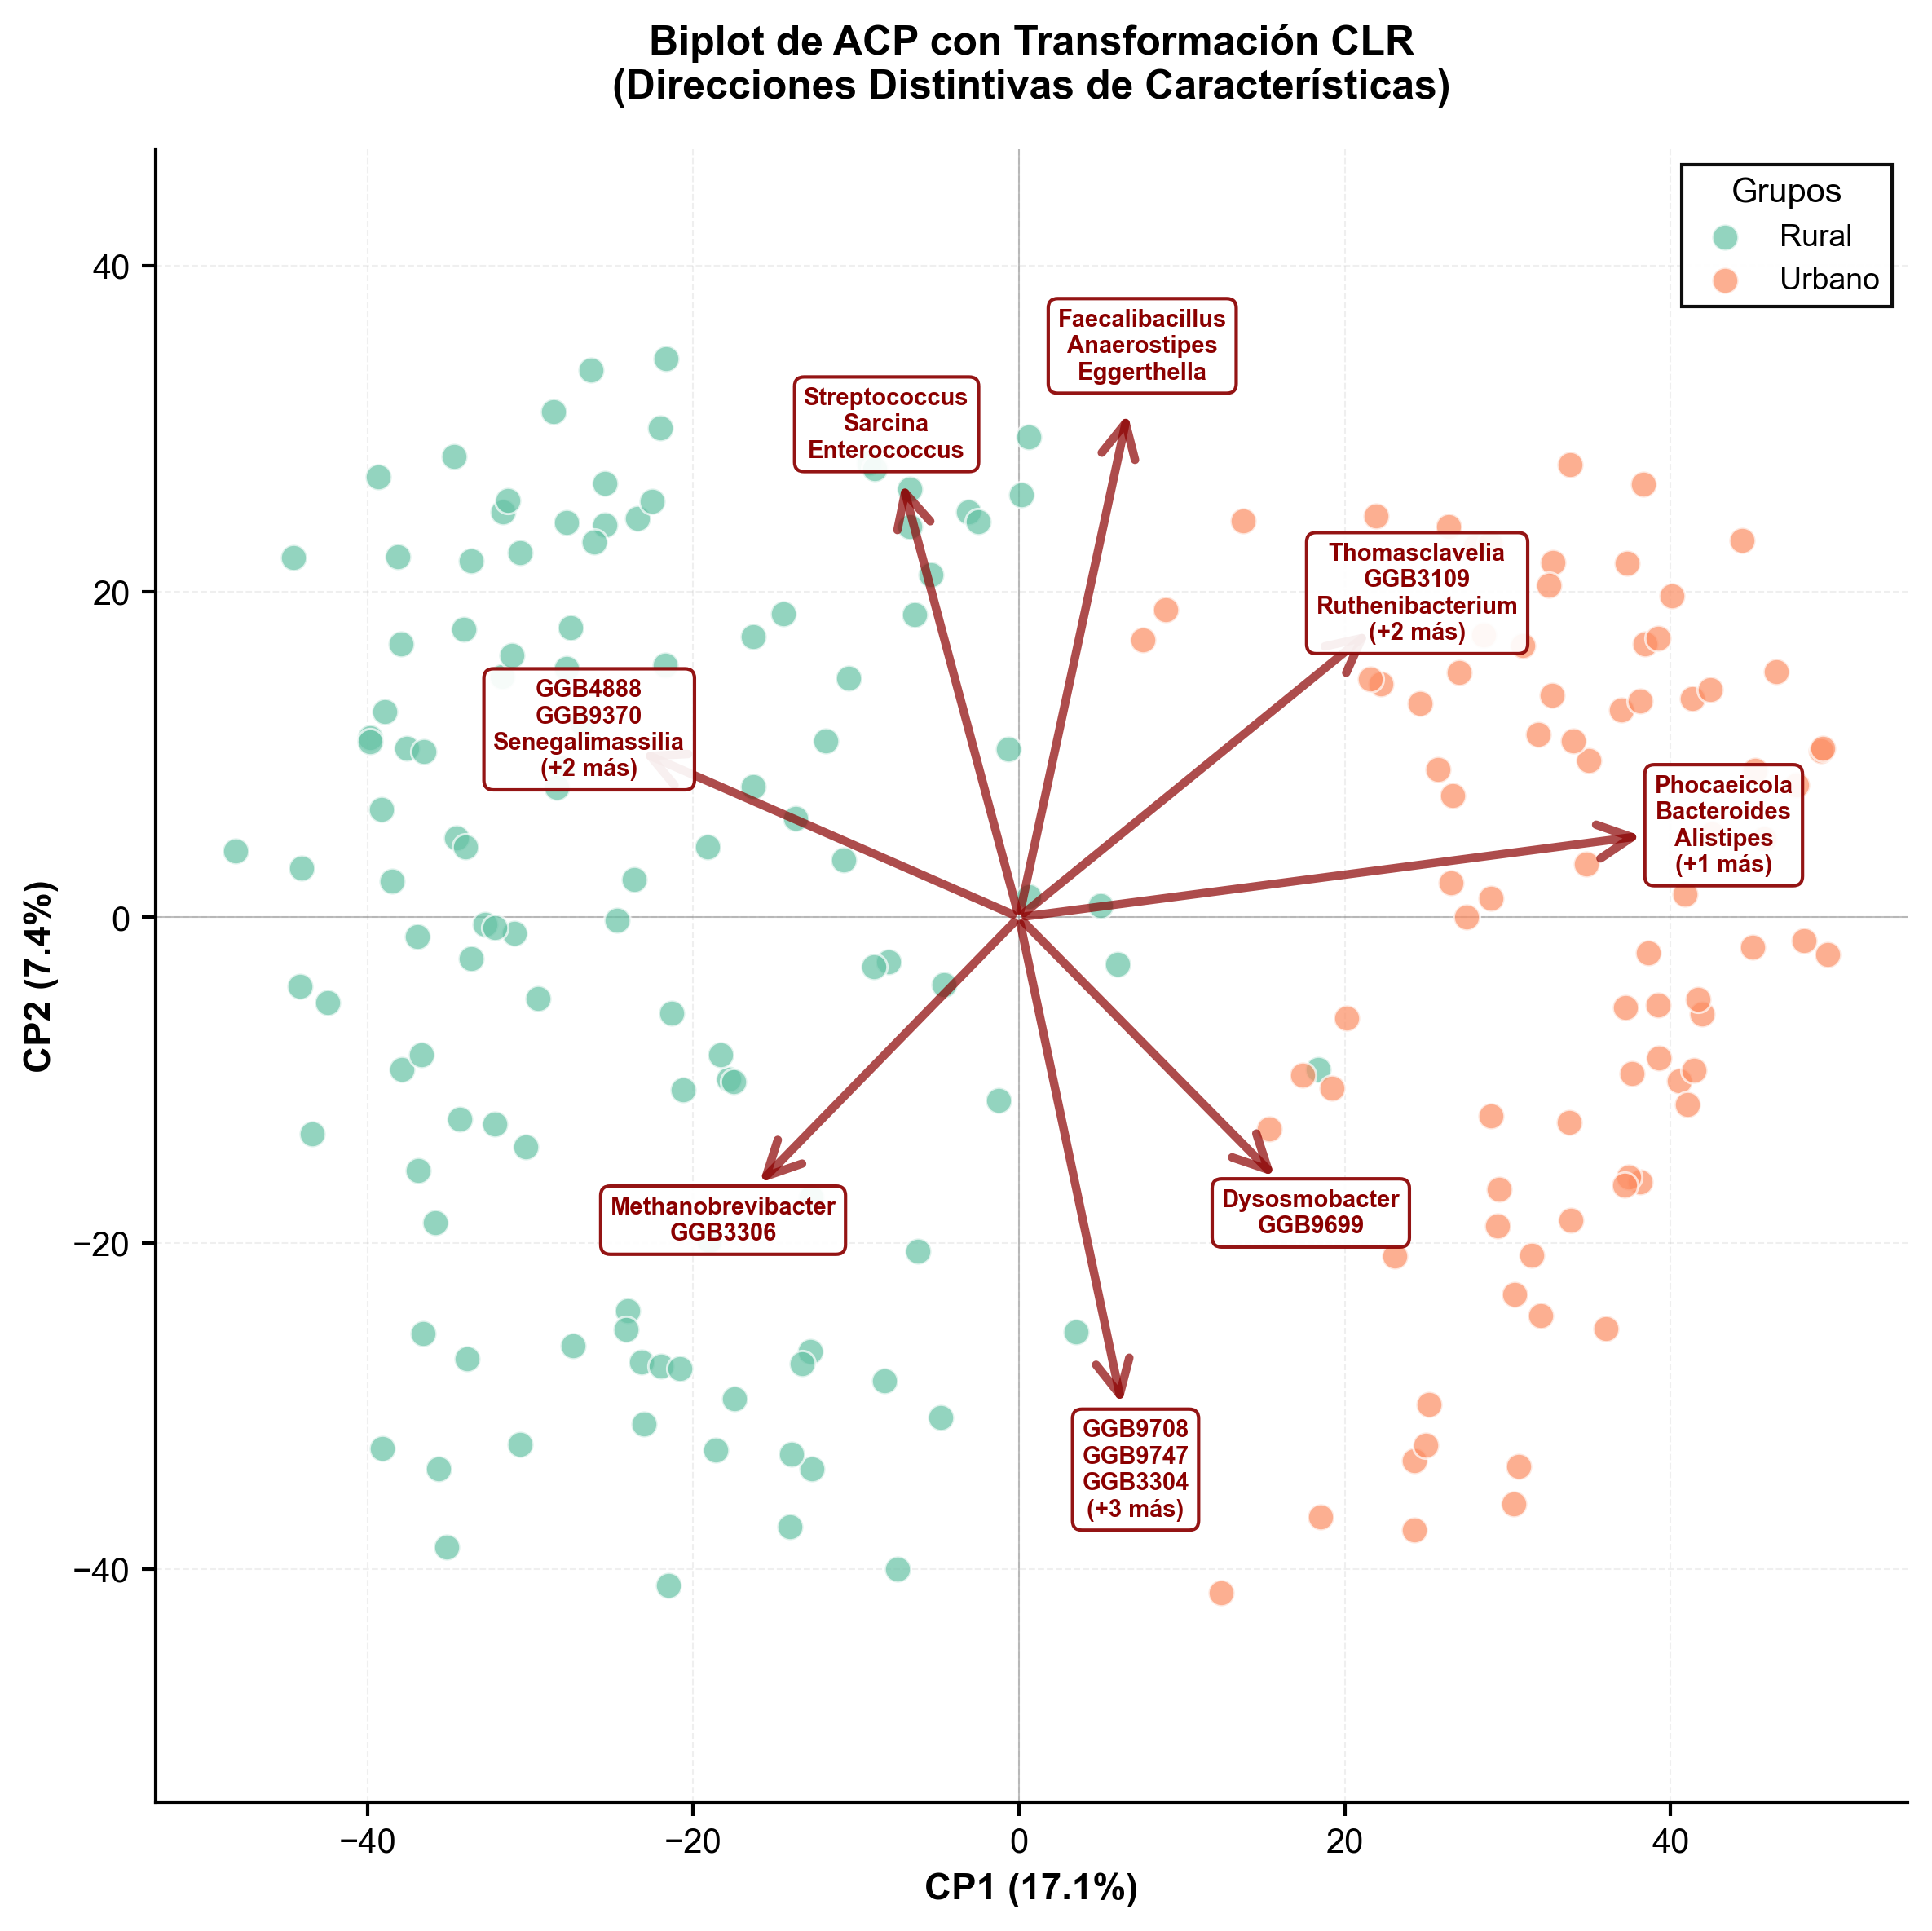

In [49]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    X_safe = X
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X_safe / geom_mean)
    
    return X_clr

# Prepare data
X = data_sp.drop(columns=['label', 'age_group', 'BMI']).values
y = data_sp['label'].values
feature_names = data_sp.drop(columns=['label', 'age_group','BMI']).columns

# Apply CLR transformation
X_clr = clr_transform(X)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Loadings (contributions of original variables)
loadings = pca.components_.T  # shape: n_features x 2

# Compute contribution of each feature to PC1+PC2
# Using absolute values because negative loadings also contribute
contrib = np.sum(np.abs(loadings), axis=1)  # Sum of absolute loadings

# Select top N features by contribution
top_n = 30  # Start with more features, then cluster them
top_idx = np.argsort(contrib)[-top_n:][::-1]
top_loadings = loadings[top_idx]
top_features = feature_names[top_idx]

# Cluster features based on their loading vectors (direction in PC space)
# Use cosine distance to group features pointing in similar directions
distances = pdist(top_loadings, metric='cosine')
linkage_matrix = linkage(distances, method='average')

# Cut tree to get clusters (adjust distance_threshold to control number of groups)
distance_threshold = 0.1  # Lower = more clusters, Higher = fewer clusters
clusters = fcluster(linkage_matrix, distance_threshold, criterion='distance')

# For each cluster, select the feature with highest contribution
selected_features = []
selected_idx = []
for cluster_id in np.unique(clusters):
    cluster_mask = clusters == cluster_id
    cluster_indices = np.where(cluster_mask)[0]
    
    # Find feature with max contribution in this cluster
    cluster_contrib = contrib[top_idx[cluster_indices]]
    best_in_cluster = cluster_indices[np.argmax(cluster_contrib)]
    
    selected_idx.append(top_idx[best_in_cluster])
    
    # Get all features in this cluster for labeling
    cluster_features = [feature_names[top_idx[i]] for i in cluster_indices]
    selected_features.append(cluster_features)

print(f"Seleccionadas {len(selected_features)} direcciones distintas de {top_n} características principales")
for i, (idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    print(f"{i+1}. Dirección {i+1}: {', '.join(feat_group)}")

# Print top contributing genera and their contributions to PCs
print("\n" + "="*80)
print("TOP GÉNEROS CONTRIBUYENTES Y SUS CONTRIBUCIONES A LOS COMPONENTES PRINCIPALES")
print("="*80)

# Get top 20 genera by total contribution
top_display = 30
top_contrib_idx = np.argsort(contrib)[-top_display:][::-1]

print(f"\n{'Ranking':<8} {'Género':<30} {'Contrib Total':<15} {'CP1':<12} {'CP2':<12}")
print("-"*80)

for rank, idx in enumerate(top_contrib_idx, 1):
    genus_name = feature_names[idx]
    total_contrib = contrib[idx]
    pc1_loading = loadings[idx, 0]
    pc2_loading = loadings[idx, 1]
    
    print(f"{rank:<8} {genus_name:<30} {total_contrib:>12.4f}   {pc1_loading:>10.4f}  {pc2_loading:>10.4f}")

print("\n" + "="*80)
print("INTERPRETACIÓN:")
print("- Contrib Total: Contribución euclidiana total a CP1+CP2 (mayor = más importante)")
print("- CP1/CP2: Loadings (correlaciones) con cada componente principal")
print("- Valores positivos: asociación positiva con el componente")
print("- Valores negativos: asociación negativa con el componente")
print("="*80 + "\n")

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

# Create SQUARE figure
fig, ax = plt.subplots(figsize=(8, 8), dpi=300)

# Get unique labels and colors
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Diccionario para traducir etiquetas (ajusta según tus datos)
label_translation = {
    'rural': 'Rural',
    'urban': 'Urbano',
    'Rural': 'Rural',
    'Urban': 'Urbano',
    # Añade más traducciones según sea necesario
}

# Add subtle grid FIRST (lowest layer)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Add reference lines at origin
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)

# Scatter plot of samples
for i, group in enumerate(labels_unique):
    idx = y == group
    # Traducir la etiqueta si existe en el diccionario
    label_es = label_translation.get(group, group)
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], 
              alpha=0.7, 
              s=60, 
              label=label_es,
              color=colors[i % len(colors)],
              edgecolors='white',
              linewidths=0.7,
              zorder=3)

# Calculate scaling factor for arrows
scaling = 200  # Adjust this value as needed

# Initialize texts list for adjustText (if using it)
texts = []

# Draw arrows with all correlated features shown
for i, (feat_idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    # Draw arrow
    ax.annotate('',
               xy=(loadings[feat_idx, 0] * scaling, loadings[feat_idx, 1] * scaling),
               xytext=(0, 0),
               arrowprops=dict(arrowstyle='->',
                             lw=2.5,
                             color='darkred',
                             mutation_scale=25,
                             alpha=0.7),
               zorder=4)
    
    # Show multiple features if they're clustered together
    if len(feat_group) == 1:
        label_text = feat_group[0]
        fontsize = 8
    else:
        # Show up to 4 features, then add "+N more"
        max_show = 3
        if len(feat_group) <= max_show:
            label_text = '\n'.join(feat_group)
        else:
            label_text = '\n'.join(feat_group[:max_show]) + f'\n(+{len(feat_group)-max_show} más)'
        fontsize = 7  # Smaller font for multiple features
    
    # Add text label
    text_offset = 1.12
    text = ax.text(loadings[feat_idx, 0] * scaling * text_offset,
                   loadings[feat_idx, 1] * scaling * text_offset,
                   label_text,
                   fontsize=fontsize,
                   color='darkred',
                   ha='center',
                   va='center',
                   fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.4',
                           facecolor='white',
                           edgecolor='darkred',
                           alpha=0.92,
                           linewidth=1),
                   zorder=5)
    texts.append(text)

# CRITICAL: Set equal aspect ratio to make plot perfectly square
ax.set_aspect('equal', adjustable='box')

# Get the current axis limits to make them symmetric
x_abs_max = max(abs(ax.get_xlim()[0]), abs(ax.get_xlim()[1]))
y_abs_max = max(abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
max_lim = max(x_abs_max, y_abs_max)

# Set symmetric limits for both axes (opcional, comentado porque usas axis('equal'))
# ax.set_xlim(-max_lim, max_lim)
# ax.set_ylim(-max_lim, max_lim)

ax.axis('equal')

# Format axes
ax.set_xlabel(f'CP1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_ylabel(f'CP2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_title('Biplot de ACP con Transformación CLR\n(Direcciones Distintivas de Características)', 
             fontsize=12, fontweight='bold', pad=15)

# Legend
ax.legend(frameon=True, 
          loc='best',
          fontsize=9,
          edgecolor='black',
          fancybox=False,
          shadow=False,
          framealpha=0.95,
          title='Grupos',
          title_fontsize=10)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Optional: Save as high-resolution files for publication
# fig.savefig('biplot_acp_clr_distinto.pdf', dpi=300, bbox_inches='tight')
# fig.savefig('biplot_acp_clr_genero_distinto.png', dpi=400, bbox_inches='tight')
# fig.savefig('biplot_acp_clr_distinto.svg', bbox_inches='tight')

Seleccionadas 8 direcciones distintas de 30 características principales
1. Dirección 1: Streptococcus, Sarcina, Enterococcus
2. Dirección 2: GGB4888, GGB9370, Senegalimassilia, Paratractidigestivibacter, GGB3588
3. Dirección 3: Faecalibacillus, Anaerostipes, Eggerthella
4. Dirección 4: Phocaeicola, Bacteroides, Alistipes, Parabacteroides
5. Dirección 5: Thomasclavelia, GGB3109, Ruthenibacterium, Flavonifractor, Dialister
6. Dirección 6: Methanobrevibacter, GGB3306
7. Dirección 7: GGB9708, GGB9747, GGB3304, GGB143497, Brotocaccenecus, GGB9707
8. Dirección 8: Dysosmobacter, GGB9699

TOP GÉNEROS CONTRIBUYENTES Y SUS CONTRIBUCIONES A LOS COMPONENTES PRINCIPALES

Ranking  Género                         Contrib Total   CP1          CP2         
--------------------------------------------------------------------------------
1        Phocaeicola                          0.2183       0.1931      0.0252
2        Thomasclavelia                       0.1979       0.1091      0.0888
3        Bacte

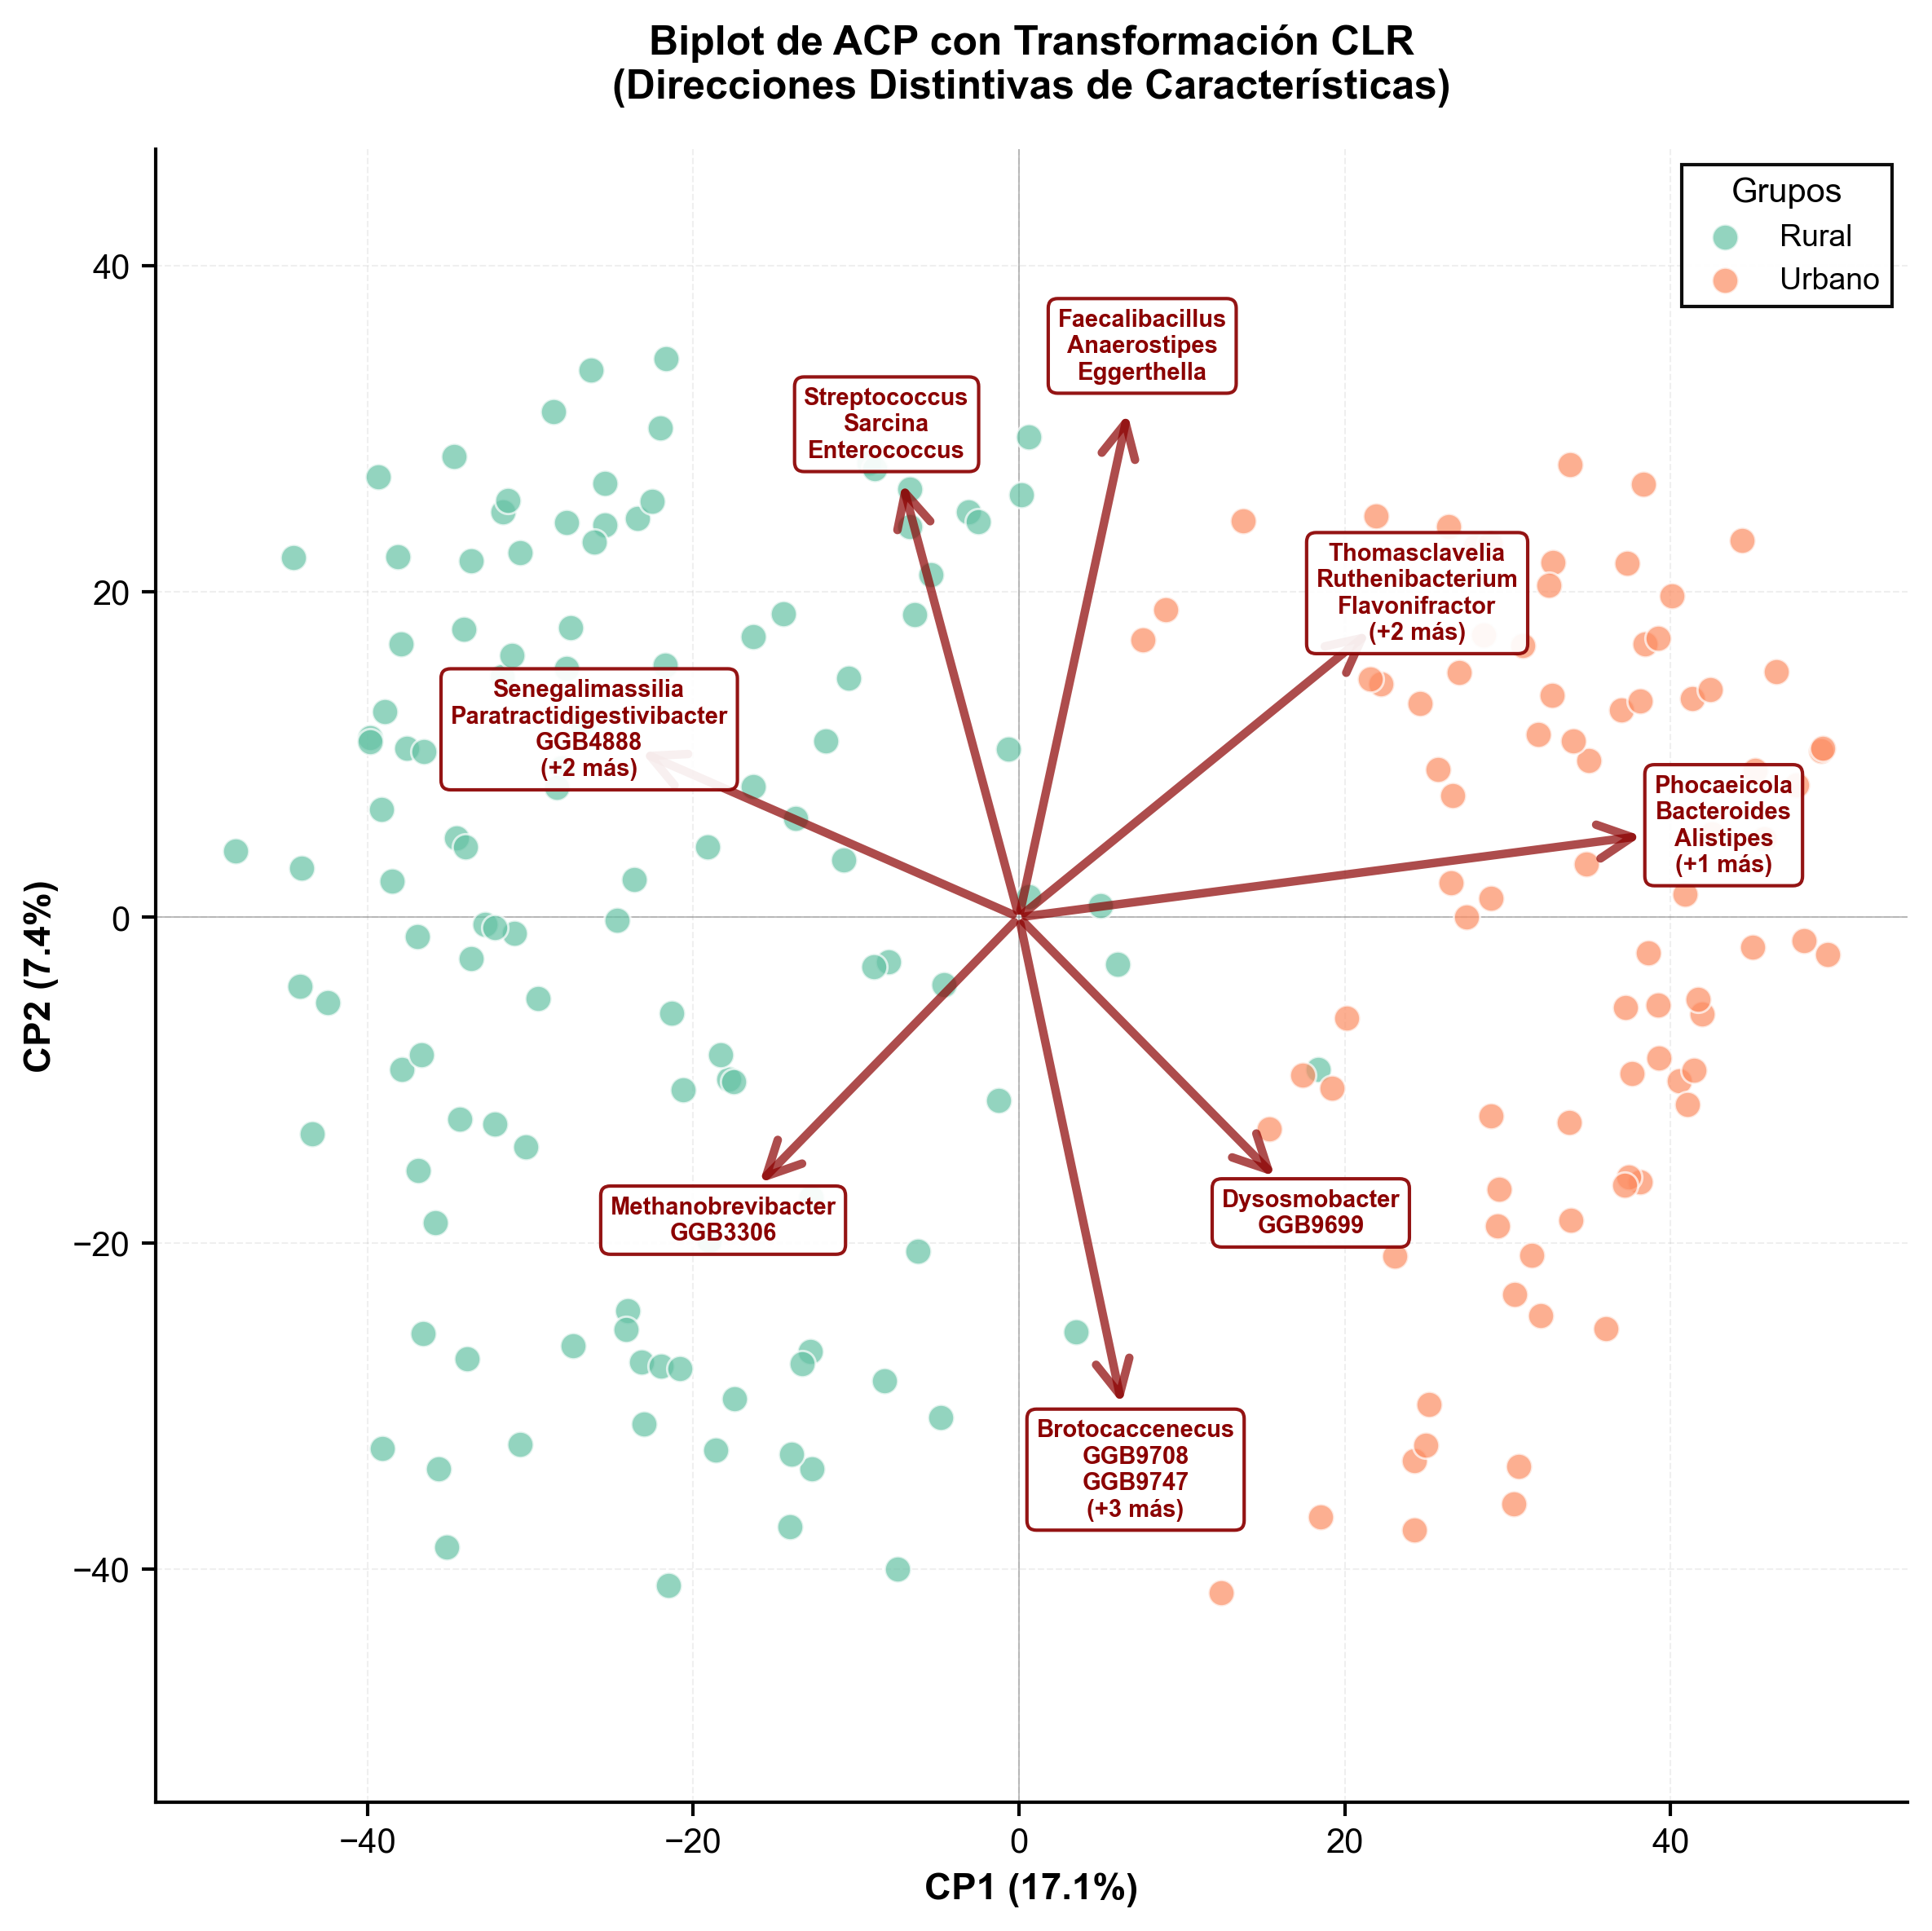

In [50]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    X_safe = X
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X_safe / geom_mean)
    
    return X_clr

# Prepare data
X = data_sp.drop(columns=['label', 'age_group', 'BMI']).values
y = data_sp['label'].values
feature_names = data_sp.drop(columns=['label', 'age_group','BMI']).columns

# Apply CLR transformation
X_clr = clr_transform(X)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Loadings (contributions of original variables)
loadings = pca.components_.T  # shape: n_features x 2

# Compute contribution of each feature to PC1+PC2
# Using absolute values because negative loadings also contribute
contrib = np.sum(np.abs(loadings), axis=1)  # Sum of absolute loadings

# Select top N features by contribution
top_n = 30  # Start with more features, then cluster them
top_idx = np.argsort(contrib)[-top_n:][::-1]
top_loadings = loadings[top_idx]
top_features = feature_names[top_idx]

# Cluster features based on their loading vectors (direction in PC space)
# Use cosine distance to group features pointing in similar directions
distances = pdist(top_loadings, metric='cosine')
linkage_matrix = linkage(distances, method='average')

# Cut tree to get clusters (adjust distance_threshold to control number of groups)
distance_threshold = 0.1  # Lower = more clusters, Higher = fewer clusters
clusters = fcluster(linkage_matrix, distance_threshold, criterion='distance')

# For each cluster, select the feature with highest contribution
selected_features = []
selected_idx = []
for cluster_id in np.unique(clusters):
    cluster_mask = clusters == cluster_id
    cluster_indices = np.where(cluster_mask)[0]
    
    # Find feature with max contribution in this cluster
    cluster_contrib = contrib[top_idx[cluster_indices]]
    best_in_cluster = cluster_indices[np.argmax(cluster_contrib)]
    
    selected_idx.append(top_idx[best_in_cluster])
    
    # Get all features in this cluster for labeling
    cluster_features = [feature_names[top_idx[i]] for i in cluster_indices]
    selected_features.append(cluster_features)

print(f"Seleccionadas {len(selected_features)} direcciones distintas de {top_n} características principales")
for i, (idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    print(f"{i+1}. Dirección {i+1}: {', '.join(feat_group)}")

# Print top contributing genera and their contributions to PCs
print("\n" + "="*80)
print("TOP GÉNEROS CONTRIBUYENTES Y SUS CONTRIBUCIONES A LOS COMPONENTES PRINCIPALES")
print("="*80)

# Get top 20 genera by total contribution
top_display = 20
top_contrib_idx = np.argsort(contrib)[-top_display:][::-1]

print(f"\n{'Ranking':<8} {'Género':<30} {'Contrib Total':<15} {'CP1':<12} {'CP2':<12}")
print("-"*80)

for rank, idx in enumerate(top_contrib_idx, 1):
    genus_name = feature_names[idx]
    total_contrib = contrib[idx]
    pc1_loading = loadings[idx, 0]
    pc2_loading = loadings[idx, 1]
    
    print(f"{rank:<8} {genus_name:<30} {total_contrib:>12.4f}   {pc1_loading:>10.4f}  {pc2_loading:>10.4f}")

print("\n" + "="*80)
print("INTERPRETACIÓN:")
print("- Contrib Total: Contribución euclidiana total a CP1+CP2 (mayor = más importante)")
print("- CP1/CP2: Loadings (correlaciones) con cada componente principal")
print("- Valores positivos: asociación positiva con el componente")
print("- Valores negativos: asociación negativa con el componente")
print("="*80 + "\n")

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

# Create SQUARE figure
fig, ax = plt.subplots(figsize=(8, 8), dpi=300)

# Get unique labels and colors
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Diccionario para traducir etiquetas (ajusta según tus datos)
label_translation = {
    'rural': 'Rural',
    'urban': 'Urbano',
    'Rural': 'Rural',
    'Urban': 'Urbano',
    # Añade más traducciones según sea necesario
}

# Add subtle grid FIRST (lowest layer)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Add reference lines at origin
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)

# Scatter plot of samples
for i, group in enumerate(labels_unique):
    idx = y == group
    # Traducir la etiqueta si existe en el diccionario
    label_es = label_translation.get(group, group)
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], 
              alpha=0.7, 
              s=60, 
              label=label_es,
              color=colors[i % len(colors)],
              edgecolors='white',
              linewidths=0.7,
              zorder=3)

# Calculate scaling factor for arrows
scaling = 200  # Adjust this value as needed

# Initialize texts list for adjustText (if using it)
texts = []

# Draw arrows with all correlated features shown
for i, (feat_idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    # Draw arrow
    ax.annotate('',
               xy=(loadings[feat_idx, 0] * scaling, loadings[feat_idx, 1] * scaling),
               xytext=(0, 0),
               arrowprops=dict(arrowstyle='->',
                             lw=2.5,
                             color='darkred',
                             mutation_scale=25,
                             alpha=0.7),
               zorder=4)
    
    # Show multiple features if they're clustered together
    if len(feat_group) == 1:
        label_text = feat_group[0]
        fontsize = 8
    else:
        # Priorizar géneros que NO empiezan con "GGB"
        # Separar en dos grupos: no-GGB y GGB
        non_ggb = [g for g in feat_group if not g.startswith('GGB')]
        ggb_genera = [g for g in feat_group if g.startswith('GGB')]
        
        # Concatenar: primero no-GGB, luego GGB
        sorted_feat_group = non_ggb + ggb_genera
        
        # Show up to 4 features, then add "+N more"
        max_show = 3
        if len(sorted_feat_group) <= max_show:
            label_text = '\n'.join(sorted_feat_group)
        else:
            label_text = '\n'.join(sorted_feat_group[:max_show]) + f'\n(+{len(sorted_feat_group)-max_show} más)'
        fontsize = 7  # Smaller font for multiple features
    
    # Add text label
    text_offset = 1.12
    text = ax.text(loadings[feat_idx, 0] * scaling * text_offset,
                   loadings[feat_idx, 1] * scaling * text_offset,
                   label_text,
                   fontsize=fontsize,
                   color='darkred',
                   ha='center',
                   va='center',
                   fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.4',
                           facecolor='white',
                           edgecolor='darkred',
                           alpha=0.92,
                           linewidth=1),
                   zorder=5)
    texts.append(text)

# CRITICAL: Set equal aspect ratio to make plot perfectly square
ax.set_aspect('equal', adjustable='box')

# Get the current axis limits to make them symmetric
x_abs_max = max(abs(ax.get_xlim()[0]), abs(ax.get_xlim()[1]))
y_abs_max = max(abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
max_lim = max(x_abs_max, y_abs_max)

# Set symmetric limits for both axes (opcional, comentado porque usas axis('equal'))
# ax.set_xlim(-max_lim, max_lim)
# ax.set_ylim(-max_lim, max_lim)

ax.axis('equal')

# Format axes
ax.set_xlabel(f'CP1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_ylabel(f'CP2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_title('Biplot de ACP con Transformación CLR\n(Direcciones Distintivas de Características)', 
             fontsize=12, fontweight='bold', pad=15)

# Legend
ax.legend(frameon=True, 
          loc='best',
          fontsize=9,
          edgecolor='black',
          fancybox=False,
          shadow=False,
          framealpha=0.95,
          title='Grupos',
          title_fontsize=10)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Optional: Save as high-resolution files for publication
# fig.savefig('biplot_acp_clr_distinto.pdf', dpi=300, bbox_inches='tight')
# fig.savefig('biplot_acp_clr_genero_distinto.png', dpi=400, bbox_inches='tight')
# fig.savefig('biplot_acp_clr_distinto.svg', bbox_inches='tight')

Seleccionadas 8 direcciones distintas de 30 características principales
1. Dirección 1: Streptococcus, Sarcina, Enterococcus
2. Dirección 2: GGB4888, GGB9370, Senegalimassilia, Paratractidigestivibacter, GGB3588
3. Dirección 3: Faecalibacillus, Anaerostipes, Eggerthella
4. Dirección 4: Phocaeicola, Bacteroides, Alistipes, Parabacteroides
5. Dirección 5: Thomasclavelia, GGB3109, Ruthenibacterium, Flavonifractor, Dialister
6. Dirección 6: Methanobrevibacter, GGB3306
7. Dirección 7: GGB9708, GGB9747, GGB3304, GGB143497, Brotocaccenecus, GGB9707
8. Dirección 8: Dysosmobacter, GGB9699

TOP GÉNEROS CONTRIBUYENTES Y SUS CONTRIBUCIONES A LOS COMPONENTES PRINCIPALES

Ranking  Género                         Contrib Total   CP1          CP2         
--------------------------------------------------------------------------------
1        Phocaeicola                          0.2183       0.1931      0.0252
2        Thomasclavelia                       0.1979       0.1091      0.0888
3        Bacte

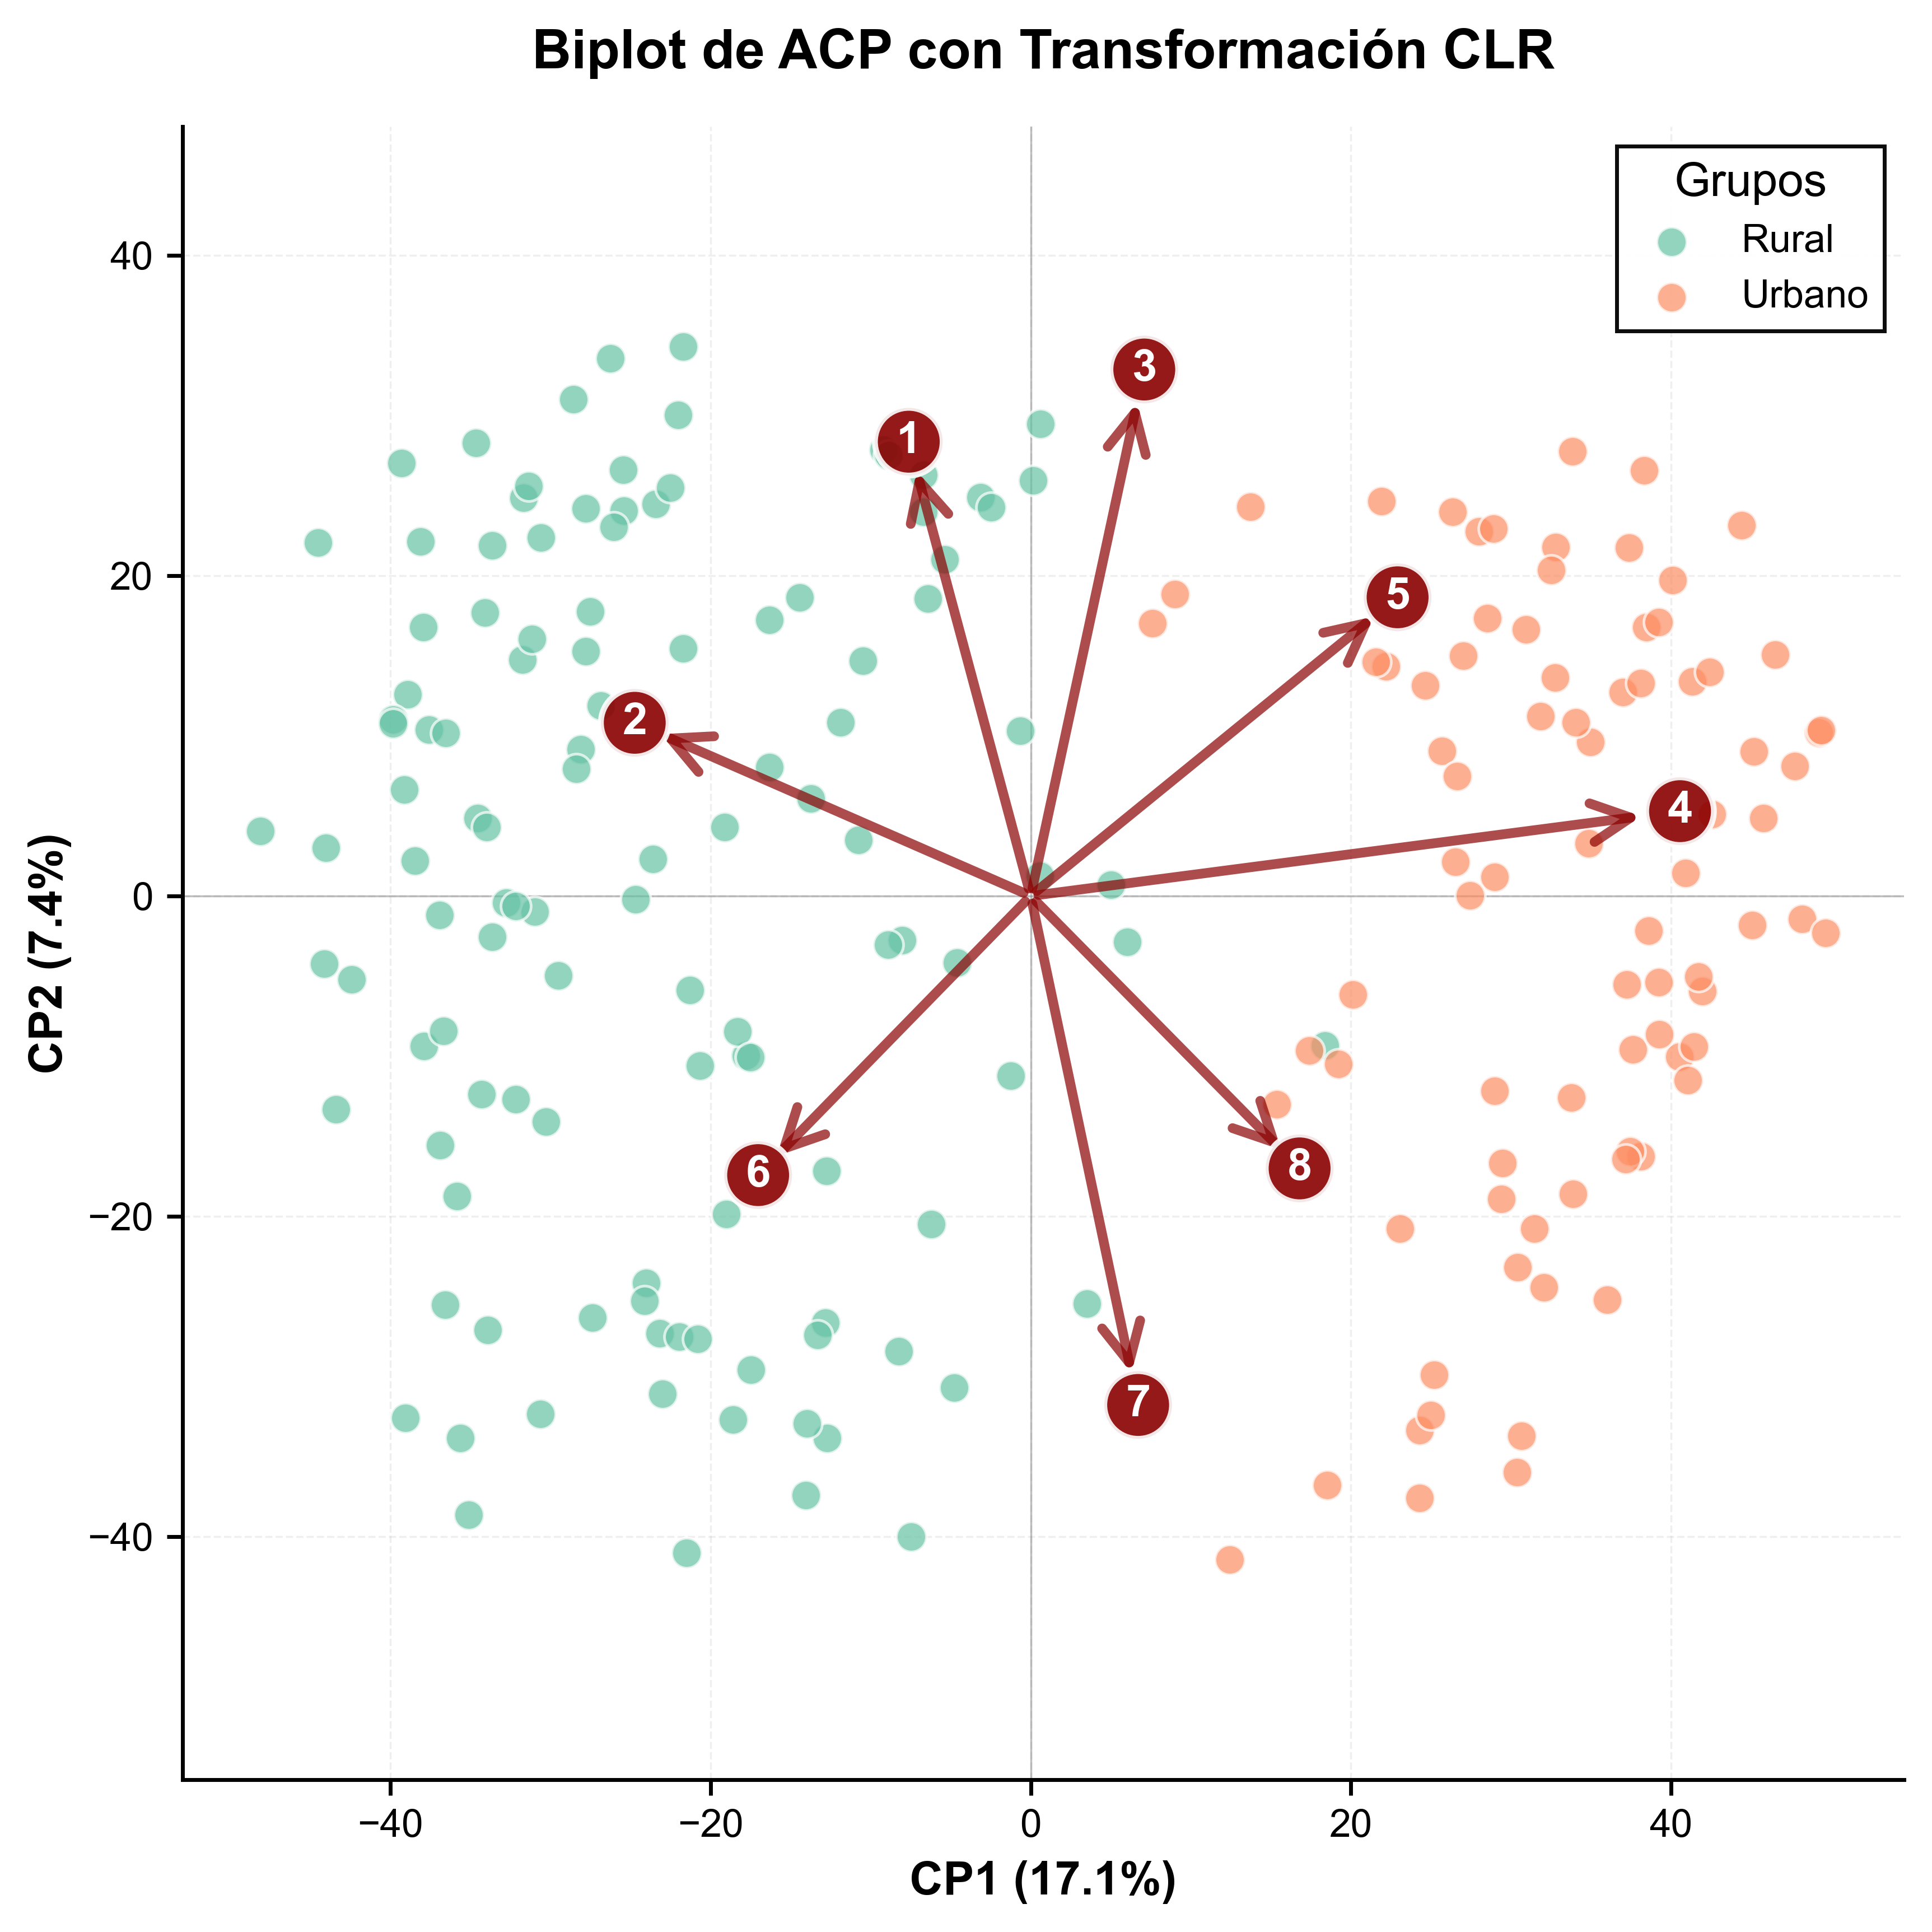


LEYENDA DE DIRECCIONES EN EL BIPLOT
1. Streptococcus, Sarcina, Enterococcus
2. Senegalimassilia, Paratractidigestivibacter, GGB4888 (+2 más)
3. Faecalibacillus, Anaerostipes, Eggerthella
4. Phocaeicola, Bacteroides, Alistipes (+1 más)
5. Thomasclavelia, Ruthenibacterium, Flavonifractor (+2 más)
6. Methanobrevibacter, GGB3306
7. Brotocaccenecus, GGB9708, GGB9747 (+3 más)
8. Dysosmobacter, GGB9699



In [51]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

# CLR transformation function
def clr_transform(X):
    """
    Apply Centered Log-Ratio (CLR) transformation to compositional data.
    
    Parameters:
    X : array-like, shape (n_samples, n_features)
        Compositional data (must be positive)
    
    Returns:
    X_clr : array, CLR-transformed data
    """
    # Add small constant to avoid log(0) if there are zeros
    X_safe = X
    
    # Compute geometric mean for each sample (row)
    geom_mean = np.exp(np.mean(np.log(X_safe), axis=1, keepdims=True))
    
    # CLR: log(x_i / geometric_mean)
    X_clr = np.log(X_safe / geom_mean)
    
    return X_clr

# Prepare data
X = data_sp.drop(columns=['label', 'age_group', 'BMI']).values
y = data_sp['label'].values
feature_names = data_sp.drop(columns=['label', 'age_group','BMI']).columns

# Apply CLR transformation
X_clr = clr_transform(X)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clr)

# Loadings (contributions of original variables)
loadings = pca.components_.T  # shape: n_features x 2

# Compute contribution of each feature to PC1+PC2
# Using absolute values because negative loadings also contribute
contrib = np.sum(np.abs(loadings), axis=1)  # Sum of absolute loadings

# Select top N features by contribution
top_n = 30  # Start with more features, then cluster them
top_idx = np.argsort(contrib)[-top_n:][::-1]
top_loadings = loadings[top_idx]
top_features = feature_names[top_idx]

# Cluster features based on their loading vectors (direction in PC space)
# Use cosine distance to group features pointing in similar directions
distances = pdist(top_loadings, metric='cosine')
linkage_matrix = linkage(distances, method='average')

# Cut tree to get clusters (adjust distance_threshold to control number of groups)
distance_threshold = 0.1  # Lower = more clusters, Higher = fewer clusters
clusters = fcluster(linkage_matrix, distance_threshold, criterion='distance')

# For each cluster, select the feature with highest contribution
selected_features = []
selected_idx = []
for cluster_id in np.unique(clusters):
    cluster_mask = clusters == cluster_id
    cluster_indices = np.where(cluster_mask)[0]
    
    # Find feature with max contribution in this cluster
    cluster_contrib = contrib[top_idx[cluster_indices]]
    best_in_cluster = cluster_indices[np.argmax(cluster_contrib)]
    
    selected_idx.append(top_idx[best_in_cluster])
    
    # Get all features in this cluster for labeling
    cluster_features = [feature_names[top_idx[i]] for i in cluster_indices]
    selected_features.append(cluster_features)

print(f"Seleccionadas {len(selected_features)} direcciones distintas de {top_n} características principales")
for i, (idx, feat_group) in enumerate(zip(selected_idx, selected_features)):
    print(f"{i+1}. Dirección {i+1}: {', '.join(feat_group)}")

# Print top contributing genera and their contributions to PCs
print("\n" + "="*80)
print("TOP GÉNEROS CONTRIBUYENTES Y SUS CONTRIBUCIONES A LOS COMPONENTES PRINCIPALES")
print("="*80)

# Get top 20 genera by total contribution
top_display = 30
top_contrib_idx = np.argsort(contrib)[-top_display:][::-1]

print(f"\n{'Ranking':<8} {'Género':<30} {'Contrib Total':<15} {'CP1':<12} {'CP2':<12}")
print("-"*80)

for rank, idx in enumerate(top_contrib_idx, 1):
    genus_name = feature_names[idx]
    total_contrib = contrib[idx]
    pc1_loading = loadings[idx, 0]
    pc2_loading = loadings[idx, 1]
    
    print(f"{rank:<8} {genus_name:<30} {total_contrib:>12.4f}   {pc1_loading:>10.4f}  {pc2_loading:>10.4f}")

print("\n" + "="*80)
print("INTERPRETACIÓN:")
print("- Contrib Total: Contribución euclidiana total a CP1+CP2 (mayor = más importante)")
print("- CP1/CP2: Loadings (correlaciones) con cada componente principal")
print("- Valores positivos: asociación positiva con el componente")
print("- Valores negativos: asociación negativa con el componente")
print("="*80 + "\n")

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

# Create SQUARE figure
fig, ax = plt.subplots(figsize=(7, 7), dpi=500)

# Get unique labels and colors
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Diccionario para traducir etiquetas (ajusta según tus datos)
label_translation = {
    'rural': 'Rural',
    'urban': 'Urbano',
    'Rural': 'Rural',
    'Urban': 'Urbano',
    # Añade más traducciones según sea necesario
}

# Add subtle grid FIRST (lowest layer)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Add reference lines at origin
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)

# Scatter plot of samples
for i, group in enumerate(labels_unique):
    idx = y == group
    # Traducir la etiqueta si existe en el diccionario
    label_es = label_translation.get(group, group)
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], 
              alpha=0.7, 
              s=60, 
              label=label_es,
              color=colors[i % len(colors)],
              edgecolors='white',
              linewidths=0.7,
              zorder=3)

# Calculate scaling factor for arrows
scaling = 200  # Adjust this value as needed

# Initialize texts list for adjustText (if using it)
texts = []

# Create a legend for the arrows
arrow_legend = []

# Draw arrows with numbered labels
for i, (feat_idx, feat_group) in enumerate(zip(selected_idx, selected_features), 1):
    # Draw arrow
    ax.annotate('',
               xy=(loadings[feat_idx, 0] * scaling, loadings[feat_idx, 1] * scaling),
               xytext=(0, 0),
               arrowprops=dict(arrowstyle='->',
                             lw=2.5,
                             color='darkred',
                             mutation_scale=25,
                             alpha=0.7),
               zorder=4)
    
    # Add numbered label at the end of arrow
    text_offset = 1.05
    text = ax.text(loadings[feat_idx, 0] * scaling * text_offset,
                   loadings[feat_idx, 1] * scaling * text_offset,
                   str(i),
                   fontsize=11.5,
                   color='white',
                   ha='center',
                   va='center',
                   fontweight='bold',
                   bbox=dict(boxstyle='circle,pad=0.3',
                           facecolor='darkred',
                           edgecolor='white',
                           alpha=0.9,
                           linewidth=1.5),
                   zorder=5)
    texts.append(text)
    
    # Prepare legend entry with prioritized genera
    # Priorizar géneros que NO empiezan con "GGB"
    non_ggb = [g for g in feat_group if not g.startswith('GGB')]
    ggb_genera = [g for g in feat_group if g.startswith('GGB')]
    sorted_feat_group = non_ggb + ggb_genera
    
    # Format the legend entry
    if len(sorted_feat_group) == 1:
        legend_text = f"{i}. {sorted_feat_group[0]}"
    elif len(sorted_feat_group) <= 3:
        legend_text = f"{i}. {', '.join(sorted_feat_group)}"
    else:
        legend_text = f"{i}. {', '.join(sorted_feat_group[:3])} (+{len(sorted_feat_group)-3} más)"
    
    arrow_legend.append(legend_text)

# CRITICAL: Set equal aspect ratio to make plot perfectly square
ax.set_aspect('equal', adjustable='box')

# Get the current axis limits to make them symmetric
x_abs_max = max(abs(ax.get_xlim()[0]), abs(ax.get_xlim()[1]))
y_abs_max = max(abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
max_lim = max(x_abs_max, y_abs_max)

# Set symmetric limits for both axes (opcional, comentado porque usas axis('equal'))
# ax.set_xlim(-max_lim, max_lim)
# ax.set_ylim(-max_lim, max_lim)

ax.axis('equal')

# Format axes
ax.set_xlabel(f'CP1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=12, fontweight='bold')
ax.set_ylabel(f'CP2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=12, fontweight='bold')
ax.set_title('Biplot de ACP con Transformación CLR', 
             fontsize=14, fontweight='bold', pad=15)

# Legend
ax.legend(frameon=True, 
          loc='best',
          fontsize=10,
          edgecolor='black',
          fancybox=False,
          shadow=False,
          framealpha=0.95,
          title='Grupos',
          title_fontsize=12)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Print arrow legend after the plot
print("\n" + "="*80)
print("LEYENDA DE DIRECCIONES EN EL BIPLOT")
print("="*80)
for entry in arrow_legend:
    print(entry)
print("="*80 + "\n")

# Optional: Save as high-resolution files for publication
# fig.savefig('biplot_acp_clr_distinto.pdf', dpi=300, bbox_inches='tight')
# fig.savefig('biplot_amalgamacion_strict_final.png', dpi=500, bbox_inches='tight')
# fig.savefig('biplot_acp_clr_distinto.svg', bbox_inches='tight')